# Cluster-mass comparison: M_cl = 300, 3000, 30000 Msun

Jupytext percent-format script.

This analysis holds fixed:
- Sigma_cloud = 0.1 g cm^-2
- epsilon_ff = 0.03
- seed = 00

and compares M_cl = 300, 3000, and 30000 Msun.

Diagrams:
- log(L/Lsun) vs Teff
- F070W-F200W vs F200W
- F182M-F200W vs F200W
- HST F555W-F814W vs F814W

The spread definition is identical to the previous full analysis:
- eligible stars have 3000 <= Teff <= 3600 K;
- H-R bins are six fixed 100 K bins;
- CMD bins are six fixed equal-width COLOR bins defined from the 1 Myr
  isochrone colors at 3000 and 3600 K;
- each bin spread is mean(upper quartile tail)-mean(lower quartile tail);
- the global spread metric is the mean over valid bins.

Expensive interpolated catalogs are cached separately for each mass/time.

In [1]:
from __future__ import annotations

import contextlib
import io
import json
import math
import os
import shutil
import sys
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.table import Column, Table
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

from spisea import atmospheres, reddening, synthetic
from nbody6tools import Reader
from nbody62spisea import converter

sys.path.append('/home/wyz5rge/synthetic-cmd-dev/cmd_generator')
import interpolator  # noqa: E402

/home/wyz5rge/.venv/nbody/lib/python3.11/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in /home/wyz5rge/SPISEA/cdbs/extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


particles.bound_subset and particles.bound_indexes will raise ImportError


## Configuration

In [2]:
UPDATED_MERGED_ROOT = Path(
    '/home/wyz5rge/SPISEA/evolution/merged/baraffe_pisa_ekstrom_parsec/'
)

SIMULATION_PATHS = {
    300: Path(
        '/standard/Tan_JC/backup_protoclusters/multiples/'
        'M300/sigma0p1/fiducial/sfe_ff003/00'
    ),
    3000: Path(
        '/standard/Tan_JC/backup_protoclusters/multiples/'
        'M3000new/sigma0p1/fiducial/sfe_ff003/00'
    ),
    30000: Path(
        '/standard/Tan_JC/backup_protoclusters/multiples/'
        'M30000/sigma0p1/fiducial/sfe_ff003/00'
    ),
}

SIGMA_CLOUD = 0.1
EPSILON_FF = 0.03
SEED = '00'

OUTPUT_DIR = Path.cwd() / 'cluster_mass_comparison_seed00_outputs'
CACHE_DIR = Path.cwd() / 'cluster_mass_comparison_seed00_cache'
ISO_CACHE_DIR = Path.cwd() / 'iso_cache'

RESET_ISO_CACHE = False
RECOMPUTE_INTERPOLATION = False
RECOMPUTE_METRICS = False
SAVE_FIGURES = True
SHOW_FIGURES = True

USE_ROTATING_MERGED = False
AKS = 0.0
DISTANCE_PC = 410.0
METALLICITY = 0.0
ATM_FUNC = atmospheres.get_BTSettl_2015_atmosphere
RED_LAW = reddening.RedLawHosek18b()

ISO_AGES_MYR = np.arange(1.0, 20.0 + 0.25, 0.5)
ISO_LOG_AGES = np.log10(ISO_AGES_MYR * 1e6)
ANALYSIS_TIMES_MYR = np.arange(1.0, 20.0 + 0.25, 0.5)
DISPLAY_TIMES_MYR = np.array([1.0, 2.0, 3.0, 5.0, 7.5, 10.0, 15.0, 20.0])

TEFF_MIN_K, TEFF_MAX_K = 3000.0, 3600.0
N_BINS = 6
HR_TEFF_BIN_EDGES_K = np.linspace(TEFF_MIN_K, TEFF_MAX_K, N_BINS + 1)
REFERENCE_BIN_AGE_MYR = 1.0
MIN_STARS_PER_BIN = 8
CLIP_YOUNG_TO_GRID = True
L_SUN_WATTS = 3.846e26

BIN_CMAP = plt.get_cmap('viridis')
AGE_CMAP = plt.get_cmap('coolwarm')
AGE_NORM = Normalize(ISO_AGES_MYR.min(), ISO_AGES_MYR.max())

FILTER_OBSMODES = {
    'F070W': 'jwst,F070W',
    'F182M': 'jwst,F182M',
    'F200W': 'jwst,F200W',
    'F555W': 'wfc3,uvis1,f555w',
    'F814W': 'wfc3,uvis1,f814w',
}
ALL_FILTERS = list(FILTER_OBSMODES.values())

## Diagram definitions

In [3]:
@dataclass(frozen=True)
class Diagram:
    key: str
    title: str
    xlabel: str
    ylabel: str
    kind: str
    blue: str | None = None
    red: str | None = None
    y_filter: str | None = None
    invert_x: bool = False
    invert_y: bool = False


DIAGRAMS = [
    Diagram('hr', r'$\log(L/L_\odot)$ vs. $T_{\rm eff}$',
            r'$T_{\rm eff}$ [K]', r'$\log(L/L_\odot)$', 'hr', invert_x=True),
    Diagram('f070w_f200w', 'F070W - F200W vs. F200W',
            'F070W - F200W', 'F200W', 'cmd',
            'F070W', 'F200W', 'F200W', invert_y=True),
    Diagram('f182m_f200w', 'F182M - F200W vs. F200W',
            'F182M - F200W', 'F200W', 'cmd',
            'F182M', 'F200W', 'F200W', invert_y=True),
    Diagram('hst_f555w_f814w', 'HST F555W - F814W vs. F814W',
            'F555W - F814W', 'F814W', 'cmd',
            'F555W', 'F814W', 'F814W', invert_y=True),
]

## General helpers

In [4]:
def show_table(df, n=None):
    df2 = df.head(n) if n is not None else df
    try:
        from IPython.display import display
        display(df2)
    except Exception:
        print(df2.to_string(index=False))


def mass_tag(mass):
    return f'M{int(mass)}'


def normalize_name(value):
    return ''.join(ch.lower() for ch in str(value) if ch.isalnum())


def prepare_dirs():
    if RESET_ISO_CACHE and ISO_CACHE_DIR.exists():
        shutil.rmtree(ISO_CACHE_DIR)
    for p in (OUTPUT_DIR, CACHE_DIR, ISO_CACHE_DIR):
        p.mkdir(parents=True, exist_ok=True)
    for mass in SIMULATION_PATHS:
        (CACHE_DIR / mass_tag(mass) / 'catalogs').mkdir(parents=True, exist_ok=True)


def finish_figure(fig, filename):
    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / filename, dpi=220, bbox_inches='tight')
    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)


prepare_dirs()
for mass, path in SIMULATION_PATHS.items():
    if not path.is_dir():
        raise FileNotFoundError(f'Missing M_cl={mass:g} simulation: {path}')

print('Simulation paths:')
for mass, path in SIMULATION_PATHS.items():
    print(f'  M_cl={mass:>5} Msun: {path}')

Simulation paths:
  M_cl=  300 Msun: /standard/Tan_JC/backup_protoclusters/multiples/M300/sigma0p1/fiducial/sfe_ff003/00
  M_cl= 3000 Msun: /standard/Tan_JC/backup_protoclusters/multiples/M3000new/sigma0p1/fiducial/sfe_ff003/00
  M_cl=30000 Msun: /standard/Tan_JC/backup_protoclusters/multiples/M30000/sigma0p1/fiducial/sfe_ff003/00


## Merged evolutionary-model reader

In [5]:
class MergedBaraffePisaEkstromParsecDAT:
    def __init__(self, root_dir: Path | str, rot=False):
        self.root_dir = Path(root_dir).expanduser().resolve()
        self.rot = bool(rot)
        self.model_dir = str(self.root_dir)
        self.z_list = [0.015]
        self.z_solar = 0.015
        self.mass_list = []
        self.grid_dir = self.root_dir / ('z015_rot' if rot else 'z015_norot')
        if not self.grid_dir.is_dir():
            raise FileNotFoundError(self.grid_dir)
        self.age_file_map = {}
        for p in sorted(self.grid_dir.glob('iso_*.dat')):
            try:
                age = float(p.stem.split('_')[1])
            except (IndexError, ValueError):
                continue
            self.age_file_map[round(age, 2)] = p
        if not self.age_file_map:
            raise FileNotFoundError(f'No iso_*.dat in {self.grid_dir}')
        self.age_list = np.array(sorted(self.age_file_map), float)

    def isochrone(self, age=1e6, metallicity=0.0):
        requested = math.log10(age)
        if requested < self.age_list[0] or requested > self.age_list[-1]:
            raise ValueError(f'logAge {requested:.4f} outside grid')
        selected = float(self.age_list[np.argmin(np.abs(self.age_list - requested))])
        path = self.age_file_map[round(selected, 2)]
        dtype = [
            ('mass', 'f8'), ('logT', 'f8'), ('logL', 'f8'), ('logg', 'f8'),
            ('logT_WR', 'f8'), ('mass_current', 'f8'), ('phase', 'i4'),
            ('model_ref', 'U32'),
        ]
        data = np.genfromtxt(path, comments='#', dtype=dtype, encoding='utf-8')
        iso = Table(np.atleast_1d(data))
        iso.add_column(Column(
            ~np.isclose(np.asarray(iso['logT'], float),
                        np.asarray(iso['logT_WR'], float),
                        rtol=0.0, atol=1e-8),
            name='isWR',
        ))
        iso.meta.update({
            'log_age': selected, 'log_age_requested': requested,
            'metallicity_in': metallicity, 'metallicity_act': 0.0,
            'source_file': str(path),
        })
        return iso


@dataclass
class IsoGrid:
    ages_myr: np.ndarray
    log_ages: np.ndarray
    isochrones: list
    coverage: pd.DataFrame
    filter_columns: dict[str, str]


def resolve_filter_column(colnames, filter_name):
    target = normalize_name(filter_name)
    candidates = [
        c for c in colnames
        if normalize_name(c).startswith('m') and normalize_name(c).endswith(target)
    ]
    instrument = 'hst' if filter_name in {'F555W', 'F814W'} else 'jwst'
    preferred = [c for c in candidates if instrument in normalize_name(c)]
    if len(preferred) == 1:
        return preferred[0]
    if len(candidates) == 1:
        return candidates[0]
    raise KeyError(f'Cannot resolve {filter_name}; candidates={candidates}')


def safe_interpolate(age_myr, mass, grid, log_ages, filters):
    try:
        with warnings.catch_warnings(), \
             contextlib.redirect_stdout(io.StringIO()), \
             contextlib.redirect_stderr(io.StringIO()):
            warnings.simplefilter('ignore')
            result = interpolator.interpolate(age_myr, mass, grid, log_ages, list(filters))
        if result is None:
            return None
        result = np.asarray(result, float)
        if result.size != 3 + len(filters) or not np.all(np.isfinite(result)):
            return None
        return result
    except Exception:
        return None


def build_iso_grid(evo_model):
    isos, records, filter_columns = [], [], None
    for age_myr, log_age in zip(ISO_AGES_MYR, ISO_LOG_AGES):
        print(f'Building/loading {age_myr:4.1f} Myr isochrone')
        try:
            iso = synthetic.IsochronePhot(
                log_age, AKS, DISTANCE_PC, metallicity=METALLICITY,
                evo_model=evo_model, atm_func=ATM_FUNC, red_law=RED_LAW,
                filters=ALL_FILTERS, iso_dir=str(ISO_CACHE_DIR),
            )
            current = {
                name: resolve_filter_column(iso.points.colnames, name)
                for name in FILTER_OBSMODES
            }
            if filter_columns is None:
                filter_columns = current
                print('Resolved magnitude columns:')
                for k, v in current.items():
                    print(f'  {k}: {v}')
            elif current != filter_columns:
                raise RuntimeError('Magnitude columns changed across ages')
            mass = np.asarray(iso.points['mass'], float)
            isos.append(iso)
            records.append({
                'age_myr': age_myr, 'status': 'success', 'n_points': len(iso.points),
                'mass_min': np.nanmin(mass), 'mass_max': np.nanmax(mass), 'error': '',
            })
        except Exception as exc:
            isos.append(None)
            records.append({
                'age_myr': age_myr, 'status': 'failed', 'n_points': 0,
                'mass_min': np.nan, 'mass_max': np.nan, 'error': str(exc),
            })
            print(f'  FAILED: {exc}')
    if filter_columns is None:
        raise RuntimeError('No isochrones built')
    return IsoGrid(
        ISO_AGES_MYR.copy(), ISO_LOG_AGES.copy(), isos,
        pd.DataFrame(records), filter_columns
    )


evo_model = MergedBaraffePisaEkstromParsecDAT(
    UPDATED_MERGED_ROOT, rot=USE_ROTATING_MERGED
)
ISO_GRID = build_iso_grid(evo_model)
ISO_GRID.coverage.to_csv(OUTPUT_DIR / 'isochrone_coverage.csv', index=False)
failed = ISO_GRID.coverage[ISO_GRID.coverage['status'] != 'success']
if len(failed):
    raise RuntimeError(f'Isochrone failures:\n{failed.to_string(index=False)}')

Building/loading  1.0 Myr isochrone
Resolved magnitude columns:
  F070W: m_jwst_F070W
  F182M: m_jwst_F182M
  F200W: m_jwst_F200W
  F555W: m_hst_f555w
  F814W: m_hst_f814w
Building/loading  1.5 Myr isochrone
Building/loading  2.0 Myr isochrone
Building/loading  2.5 Myr isochrone
Building/loading  3.0 Myr isochrone
Building/loading  3.5 Myr isochrone
Building/loading  4.0 Myr isochrone


Building/loading  4.5 Myr isochrone


Building/loading  5.0 Myr isochrone
Building/loading  5.5 Myr isochrone
Building/loading  6.0 Myr isochrone
Building/loading  6.5 Myr isochrone
Building/loading  7.0 Myr isochrone
Building/loading  7.5 Myr isochrone
Building/loading  8.0 Myr isochrone


Building/loading  8.5 Myr isochrone


Building/loading  9.0 Myr isochrone
Building/loading  9.5 Myr isochrone
Building/loading 10.0 Myr isochrone
Building/loading 10.5 Myr isochrone
Building/loading 11.0 Myr isochrone
Building/loading 11.5 Myr isochrone


Building/loading 12.0 Myr isochrone


Building/loading 12.5 Myr isochrone
Building/loading 13.0 Myr isochrone
Building/loading 13.5 Myr isochrone
Building/loading 14.0 Myr isochrone
Building/loading 14.5 Myr isochrone
Building/loading 15.0 Myr isochrone
Building/loading 15.5 Myr isochrone


Building/loading 16.0 Myr isochrone


Building/loading 16.5 Myr isochrone
Building/loading 17.0 Myr isochrone
Building/loading 17.5 Myr isochrone
Building/loading 18.0 Myr isochrone
Building/loading 18.5 Myr isochrone
Building/loading 19.0 Myr isochrone
Building/loading 19.5 Myr isochrone


Building/loading 20.0 Myr isochrone


## Diagram coordinates and fixed 1 Myr bins

In [6]:
def nearest_iso_index(age_myr):
    age = np.clip(age_myr, ISO_GRID.ages_myr.min(), ISO_GRID.ages_myr.max())
    return int(np.argmin(np.abs(ISO_GRID.ages_myr - age)))


def catalog_xy(df, diagram):
    if diagram.kind == 'hr':
        return df['teff'].to_numpy(float), df['log_luminosity_lsun'].to_numpy(float)
    blue = df[f'mag_{diagram.blue}'].to_numpy(float)
    red = df[f'mag_{diagram.red}'].to_numpy(float)
    y = df[f'mag_{diagram.y_filter}'].to_numpy(float)
    return blue - red, y


def isochrone_xy(iso, diagram):
    teff = np.asarray(iso.points['Teff'], float)
    if diagram.kind == 'hr':
        lum = np.asarray(iso.points['L'], float)
        y = np.full_like(lum, np.nan)
        good = np.isfinite(lum) & (lum > 0)
        y[good] = np.log10(lum[good] / L_SUN_WATTS)
        return teff, y, teff
    blue = np.asarray(iso.points[ISO_GRID.filter_columns[diagram.blue]], float)
    red = np.asarray(iso.points[ISO_GRID.filter_columns[diagram.red]], float)
    y = np.asarray(iso.points[ISO_GRID.filter_columns[diagram.y_filter]], float)
    return blue - red, y, teff


def interpolate_color_at_teff(iso, diagram, target, half_width=250.0):
    color, _, teff = isochrone_xy(iso, diagram)
    good = (
        np.isfinite(color) & np.isfinite(teff)
        & (teff >= target - half_width) & (teff <= target + half_width)
    )
    t, c = teff[good], color[good]
    if len(t) < 2:
        raise RuntimeError(f'Not enough points near {target:g} K for {diagram.key}')
    order = np.argsort(t)
    t, c = t[order], c[order]
    ut, inv = np.unique(t, return_inverse=True)
    sums, counts = np.zeros_like(ut), np.zeros_like(ut)
    np.add.at(sums, inv, c)
    np.add.at(counts, inv, 1)
    uc = sums / counts
    if target < ut.min() or target > ut.max():
        raise RuntimeError(f'{target:g} K not bracketed for {diagram.key}')
    return float(np.interp(target, ut, uc))


def build_static_bins():
    idx = nearest_iso_index(REFERENCE_BIN_AGE_MYR)
    if not np.isclose(ISO_GRID.ages_myr[idx], REFERENCE_BIN_AGE_MYR):
        raise RuntimeError('1 Myr reference isochrone unavailable')
    iso = ISO_GRID.isochrones[idx]
    out = {}
    for d in DIAGRAMS:
        if d.kind == 'hr':
            edges = HR_TEFF_BIN_EDGES_K.copy()
            x3000, x3600 = TEFF_MIN_K, TEFF_MAX_K
        else:
            x3000 = interpolate_color_at_teff(iso, d, TEFF_MIN_K)
            x3600 = interpolate_color_at_teff(iso, d, TEFF_MAX_K)
            edges = np.linspace(min(x3000, x3600), max(x3000, x3600), N_BINS + 1)
        out[d.key] = {
            'edges': edges, 'x_3000': x3000, 'x_3600': x3600,
            'bin_width': float(edges[1] - edges[0]),
        }
    return out


STATIC_BINS = build_static_bins()
static_rows = []
for d in DIAGRAMS:
    z = STATIC_BINS[d.key]
    for i, edge in enumerate(z['edges']):
        static_rows.append({
            'diagram': d.key, 'diagram_title': d.title,
            'reference_isochrone_age_myr': REFERENCE_BIN_AGE_MYR,
            'x_at_3000k': z['x_3000'], 'x_at_3600k': z['x_3600'],
            'edge_index': i, 'x_edge': float(edge), 'bin_width': z['bin_width'],
        })
pd.DataFrame(static_rows).to_csv(
    OUTPUT_DIR / 'static_1myr_bin_definitions.csv', index=False
)


def intervals(edges):
    return [(float(edges[i]), float(edges[i + 1])) for i in range(len(edges) - 1)]


def interval_mask(values, low, high, is_last=False):
    values = np.asarray(values, float)
    if is_last:
        return (values >= low) & (values <= high)
    return (values >= low) & (values < high)


def target_temperature_mask(teff):
    teff = np.asarray(teff, float)
    return np.isfinite(teff) & (teff >= TEFF_MIN_K) & (teff <= TEFF_MAX_K)

## Snapshot loading and interpolation

In [7]:
def load_finite_table(sim_path, time_myr):
    path = os.path.abspath(str(sim_path))
    if not path.endswith('/'):
        path += '/'
    snapshot = Reader.read_snapshot(path, time=float(time_myr))
    snapshot.to_physical()
    with warnings.catch_warnings():
        warnings.filterwarnings(
            'ignore', message='divide by zero encountered in log10',
            category=RuntimeWarning,
        )
        table = converter.to_spicea_table(snapshot)
    return table


FILTER_NAMES = list(FILTER_OBSMODES)
FILTER_KEYS = [ISO_GRID.filter_columns[n] for n in FILTER_NAMES]
CATALOG_COLUMNS = [
    'mass', 'age_myr', 'age_used_myr', 'age_clipped_to_grid', 'teff',
    'luminosity_watts', 'log_luminosity_lsun', 'logg',
    *[f'mag_{name}' for name in FILTER_NAMES],
]


def interpolate_population(masses, ages):
    rows = []
    counters = {
        'n_input': int(len(masses)), 'nonfinite_mass': 0, 'nonpositive_mass': 0,
        'nonfinite_age': 0, 'younger_than_grid': 0, 'older_than_grid': 0,
        'interpolation_failed': 0, 'nonpositive_luminosity': 0, 'retained': 0,
    }
    amin, amax = float(ISO_GRID.ages_myr.min()), float(ISO_GRID.ages_myr.max())
    for mass, age in zip(masses, ages):
        mass, age = float(mass), float(age)
        if not np.isfinite(mass):
            counters['nonfinite_mass'] += 1; continue
        if mass <= 0:
            counters['nonpositive_mass'] += 1; continue
        if not np.isfinite(age):
            counters['nonfinite_age'] += 1; continue
        used_age, clipped = age, False
        if used_age < amin:
            counters['younger_than_grid'] += 1
            if not CLIP_YOUNG_TO_GRID:
                continue
            used_age, clipped = amin, True
        if used_age > amax:
            counters['older_than_grid'] += 1; continue
        result = safe_interpolate(
            used_age, mass, ISO_GRID.isochrones, ISO_GRID.log_ages, FILTER_KEYS
        )
        if result is None:
            counters['interpolation_failed'] += 1; continue
        luminosity, teff, logg = map(float, result[:3])
        if not np.isfinite(luminosity) or luminosity <= 0:
            counters['nonpositive_luminosity'] += 1; continue
        row = {
            'mass': mass, 'age_myr': age, 'age_used_myr': used_age,
            'age_clipped_to_grid': clipped, 'teff': teff,
            'luminosity_watts': luminosity,
            'log_luminosity_lsun': np.log10(luminosity / L_SUN_WATTS),
            'logg': logg,
        }
        row.update({
            f'mag_{name}': float(value)
            for name, value in zip(FILTER_NAMES, result[3:])
        })
        rows.append(row)
        counters['retained'] += 1
    return pd.DataFrame(rows, columns=CATALOG_COLUMNS), counters

## Interpolation cache

In [8]:
def catalog_cache_paths(cluster_mass, time_myr):
    root = CACHE_DIR / mass_tag(cluster_mass) / 'catalogs'
    stem = f't{float(time_myr):04.1f}myr'
    return root / f'catalog_{stem}.csv', root / f'accounting_{stem}.json'


def save_cached_catalog(cluster_mass, time_myr, df, accounting):
    csv_path, json_path = catalog_cache_paths(cluster_mass, time_myr)
    df.to_csv(csv_path, index=False)
    json_path.write_text(json.dumps(accounting, indent=2))


def load_cached_catalog(cluster_mass, time_myr):
    csv_path, json_path = catalog_cache_paths(cluster_mass, time_myr)
    return pd.read_csv(csv_path), json.loads(json_path.read_text())


catalogs = {}
accounting_rows = []

for cluster_mass, sim_path in SIMULATION_PATHS.items():
    print('=' * 80)
    print(f'M_cl = {cluster_mass:g} Msun')
    for time_myr in ANALYSIS_TIMES_MYR:
        time_myr = float(time_myr)
        csv_path, json_path = catalog_cache_paths(cluster_mass, time_myr)
        if csv_path.exists() and json_path.exists() and not RECOMPUTE_INTERPOLATION:
            df, accounting = load_cached_catalog(cluster_mass, time_myr)
            print(f'  t={time_myr:4.1f}: cached {len(df)} systems')
        else:
            print(f'  t={time_myr:4.1f}: loading/interpolating')
            try:
                table = load_finite_table(sim_path, time_myr)
                df, counters = interpolate_population(
                    np.asarray(table['mass'], float),
                    np.asarray(table['age'], float),
                )
                accounting = {
                    'cluster_mass_msun': int(cluster_mass),
                    'sigma_cloud_g_cm2': SIGMA_CLOUD,
                    'epsilon_ff': EPSILON_FF,
                    'seed': SEED,
                    'snapshot_time_myr': time_myr,
                    'status': 'success', 'error': '', **counters,
                }
                save_cached_catalog(cluster_mass, time_myr, df, accounting)
            except Exception as exc:
                print(f'    FAILED: {exc}')
                df = pd.DataFrame(columns=CATALOG_COLUMNS)
                accounting = {
                    'cluster_mass_msun': int(cluster_mass),
                    'sigma_cloud_g_cm2': SIGMA_CLOUD,
                    'epsilon_ff': EPSILON_FF,
                    'seed': SEED,
                    'snapshot_time_myr': time_myr,
                    'status': 'failed', 'error': str(exc),
                    'n_input': 0, 'retained': 0,
                }
        catalogs[(int(cluster_mass), time_myr)] = df
        accounting_rows.append(accounting)


df_accounting = pd.DataFrame(accounting_rows)
df_accounting.to_csv(OUTPUT_DIR / 'interpolation_accounting.csv', index=False)
show_table(df_accounting)

M_cl = 300 Msun
  t= 1.0: loading/interpolating


  t= 1.5: loading/interpolating


  t= 2.0: loading/interpolating


  t= 2.5: loading/interpolating


  t= 3.0: loading/interpolating


...

  t=18.5: loading/interpolating


  t=19.0: loading/interpolating


  t=19.5: loading/interpolating


  t=20.0: loading/interpolating


,cluster_mass_msun,sigma_cloud_g_cm2,epsilon_ff,seed,snapshot_time_myr,status,error,n_input,nonfinite_mass,nonpositive_mass,nonfinite_age,younger_than_grid,older_than_grid,interpolation_failed,nonpositive_luminosity,retained
0,300,0.1,0.03,00,1.0,success,,190,0,0,0,83,0,0,0,190
1,300,0.1,0.03,00,1.5,success,,215,0,0,0,78,0,0,0,215
2,300,0.1,0.03,00,2.0,success,,268,0,0,0,73,0,0,0,268
3,300,0.1,0.03,00,2.5,success,,290,0,0,0,72,0,0,0,290
4,300,0.1,0.03,00,3.0,success,,293,0,0,0,22,0,0,0,293
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,30000,0.1,0.03,00,18.0,success,,27179,0,0,0,0,0,58,0,27121
113,30000,0.1,0.03,00,18.5,success,,27183,0,0,0,0,0,59,0,27124
114,30000,0.1,0.03,00,19.0,success,,27191,0,0,0,0,0,63,0,27128
115,30000,0.1,0.03,00,19.5,success,,27190,0,0,0,0,0,65,0,27125


## Spread metric

In [9]:
def tail_spread(values):
    v = np.asarray(values, float)
    v = v[np.isfinite(v)]
    if len(v) == 0:
        return np.nan, np.nan, np.nan
    q25, q75 = np.quantile(v, [0.25, 0.75])
    lo, hi = v[v <= q25], v[v >= q75]
    if len(lo) == 0 or len(hi) == 0:
        return np.nan, np.nan, np.nan
    lmean, hmean = float(lo.mean()), float(hi.mean())
    return hmean - lmean, lmean, hmean


def measure(df, diagram, cluster_mass, time_myr):
    edges = np.asarray(STATIC_BINS[diagram.key]['edges'], float)
    x, y = catalog_xy(df, diagram)
    teff = df['teff'].to_numpy(float)
    finite = np.isfinite(x) & np.isfinite(y) & np.isfinite(teff)
    teff_ok = finite & target_temperature_mask(teff)
    full_span = finite & interval_mask(x, edges[0], edges[-1], True)
    total_in_span = int(full_span.sum())
    total_rejected = int((full_span & ~teff_ok).sum())

    bins = []
    for i, (low, high) in enumerate(intervals(edges)):
        x_bin = finite & interval_mask(x, low, high, i == N_BINS - 1)
        accepted = x_bin & teff_ok
        yb, tb = y[accepted], teff[accepted]
        spread = lower = upper = np.nan
        if len(yb) >= MIN_STARS_PER_BIN:
            spread, lower, upper = tail_spread(yb)
        bins.append({
            'cluster_mass_msun': int(cluster_mass),
            'sigma_cloud_g_cm2': SIGMA_CLOUD, 'epsilon_ff': EPSILON_FF,
            'seed': SEED, 'snapshot_time_myr': float(time_myr),
            'diagram': diagram.key, 'diagram_title': diagram.title,
            'bin_index': i, 'x_low': low, 'x_high': high, 'x_width': high - low,
            'n_x_selected_before_teff_cut': int(x_bin.sum()),
            'n_rejected_by_teff_cut': int((x_bin & ~teff_ok).sum()),
            'n_stars': int(accepted.sum()),
            'retained_teff_min_k': float(np.min(tb)) if len(tb) else np.nan,
            'retained_teff_max_k': float(np.max(tb)) if len(tb) else np.nan,
            'lower_tail_mean_y': lower, 'upper_tail_mean_y': upper,
            'bin_spread': spread, 'valid_bin': bool(np.isfinite(spread)),
        })

    valid = np.array([r['bin_spread'] for r in bins if r['valid_bin']], float)
    dt90 = (
        float(np.percentile(df['age_myr'], 95) - np.percentile(df['age_myr'], 5))
        if len(df) else np.nan
    )
    summary = {
        'cluster_mass_msun': int(cluster_mass),
        'sigma_cloud_g_cm2': SIGMA_CLOUD, 'epsilon_ff': EPSILON_FF,
        'seed': SEED, 'snapshot_time_myr': float(time_myr),
        'diagram': diagram.key, 'diagram_title': diagram.title,
        'spread_metric': float(valid.mean()) if len(valid) else np.nan,
        'n_valid_bins': len(valid), 'n_total_bins': N_BINS,
        'n_catalog_stars': len(df),
        'n_in_full_x_span_before_teff_cut': total_in_span,
        'n_rejected_by_teff_cut': total_rejected,
        'fraction_full_x_span_rejected_by_teff': (
            total_rejected / total_in_span if total_in_span else np.nan
        ),
        'n_retained_in_temperature_band': int(teff_ok.sum()),
        'age_spread_p95_minus_p05_myr': dt90,
    }
    return summary, bins

## Metric cache

In [10]:
METRIC_SUMMARY_PATH = CACHE_DIR / 'spread_summary.csv'
METRIC_BINS_PATH = CACHE_DIR / 'spread_bins.csv'

if (
    METRIC_SUMMARY_PATH.exists() and METRIC_BINS_PATH.exists()
    and not RECOMPUTE_METRICS and not RECOMPUTE_INTERPOLATION
):
    print('Loading cached spread metrics')
    df_metrics = pd.read_csv(METRIC_SUMMARY_PATH, dtype={'seed': str})
    df_bins = pd.read_csv(METRIC_BINS_PATH, dtype={'seed': str})
else:
    metric_rows, bin_rows = [], []
    for cluster_mass in SIMULATION_PATHS:
        for time_myr in ANALYSIS_TIMES_MYR:
            time_myr = float(time_myr)
            df = catalogs[(int(cluster_mass), time_myr)]
            if df.empty:
                continue
            for diagram in DIAGRAMS:
                summary, details = measure(df, diagram, cluster_mass, time_myr)
                metric_rows.append(summary)
                bin_rows.extend(details)
    df_metrics = pd.DataFrame(metric_rows)
    df_bins = pd.DataFrame(bin_rows)
    df_metrics.to_csv(METRIC_SUMMARY_PATH, index=False)
    df_bins.to_csv(METRIC_BINS_PATH, index=False)


df_metrics.to_csv(
    OUTPUT_DIR / 'spread_metrics_by_mass_time_and_diagram.csv', index=False
)
df_bins.to_csv(OUTPUT_DIR / 'spread_metrics_per_bin.csv', index=False)
show_table(df_metrics.head(20))

,cluster_mass_msun,sigma_cloud_g_cm2,epsilon_ff,seed,snapshot_time_myr,diagram,diagram_title,spread_metric,n_valid_bins,n_total_bins,n_catalog_stars,n_in_full_x_span_before_teff_cut,n_rejected_by_teff_cut,fraction_full_x_span_rejected_by_teff,n_retained_in_temperature_band,age_spread_p95_minus_p05_myr
0,300,0.1,0.03,00,1.0,hr,$\log(L/L_\odot)$ vs. $T_{\rm eff}$,0.081328,4,6,190,70,0,0.000000,70,0.816815
1,300,0.1,0.03,00,1.0,f070w_f200w,F070W - F200W vs. F200W,0.228125,4,6,190,70,0,0.000000,70,0.816815
2,300,0.1,0.03,00,1.0,f182m_f200w,F182M - F200W vs. F200W,0.194787,5,6,190,70,0,0.000000,70,0.816815
3,300,0.1,0.03,00,1.0,hst_f555w_f814w,HST F555W - F814W vs. F814W,0.262138,4,6,190,70,0,0.000000,70,0.816815
4,300,0.1,0.03,00,1.5,hr,$\log(L/L_\odot)$ vs. $T_{\rm eff}$,0.197010,5,6,215,83,0,0.000000,83,1.332134
5,300,0.1,0.03,00,1.5,f070w_f200w,F070W - F200W vs. F200W,0.631390,5,6,215,86,4,0.046512,83,1.332134
6,300,0.1,0.03,00,1.5,f182m_f200w,F182M - F200W vs. F200W,0.330562,5,6,215,78,2,0.025641,83,1.332134
7,300,0.1,0.03,00,1.5,hst_f555w_f814w,HST F555W - F814W vs. F814W,0.554483,5,6,215,84,1,0.011905,83,1.332134
8,300,0.1,0.03,00,2.0,hr,$\log(L/L_\odot)$ vs. $T_{\rm eff}$,0.245771,6,6,268,99,0,0.000000,99,1.893711
9,300,0.1,0.03,00,2.0,f070w_f200w,F070W - F200W vs. F200W,0.802348,6,6,268,101,5,0.049505,99,1.893711


## Coverage diagnostics

M_cl=300 may have bins with fewer than eight stars. We deliberately keep
MIN_STARS_PER_BIN=8 for the first comparison so the definition is identical
for all three masses. The coverage table makes sparse-bin failures explicit.

In [11]:
coverage = df_metrics[[
    'cluster_mass_msun', 'snapshot_time_myr', 'diagram',
    'n_catalog_stars', 'n_retained_in_temperature_band',
    'n_valid_bins', 'spread_metric',
]].sort_values(['diagram', 'snapshot_time_myr', 'cluster_mass_msun'])
coverage.to_csv(OUTPUT_DIR / 'metric_coverage_by_cluster_mass.csv', index=False)

coverage_summary = (
    coverage.groupby(['cluster_mass_msun', 'diagram'], as_index=False)
    .agg(
        mean_valid_bins=('n_valid_bins', 'mean'),
        min_valid_bins=('n_valid_bins', 'min'),
        max_valid_bins=('n_valid_bins', 'max'),
        n_finite_metrics=(
            'spread_metric',
            lambda x: int(np.isfinite(pd.to_numeric(x, errors='coerce')).sum()),
        ),
    )
)
print('Coverage summary:')
show_table(coverage_summary)
coverage_summary.to_csv(OUTPUT_DIR / 'metric_coverage_summary.csv', index=False)

Coverage summary:


,cluster_mass_msun,diagram,mean_valid_bins,min_valid_bins,max_valid_bins,n_finite_metrics
0,300,f070w_f200w,4.769231,4,6,39
1,300,f182m_f200w,4.384615,4,6,39
2,300,hr,5.923077,4,6,39
3,300,hst_f555w_f814w,5.179487,4,6,39
4,3000,f070w_f200w,5.410256,5,6,39
5,3000,f182m_f200w,5.025641,4,6,39
6,3000,hr,6.000000,6,6,39
7,3000,hst_f555w_f814w,5.948718,5,6,39
8,30000,f070w_f200w,5.717949,5,6,39
9,30000,f182m_f200w,5.692308,5,6,39


## Plot helpers

In [12]:
def shade_bins(ax, diagram):
    edges = np.asarray(STATIC_BINS[diagram.key]['edges'], float)
    spans = intervals(edges)
    for i, (low, high) in enumerate(spans):
        color = BIN_CMAP((i + 0.5) / N_BINS)
        ax.axvspan(low, high, color=color, alpha=0.14, linewidth=0, zorder=0)
        ax.axvline(low, color=color, alpha=0.65, linewidth=0.8, zorder=1)
    ax.axvline(
        spans[-1][1], color=BIN_CMAP((N_BINS - 0.5) / N_BINS),
        alpha=0.65, linewidth=0.8, zorder=1,
    )


def metric_row(cluster_mass, time_myr, diagram_key):
    return df_metrics[
        (df_metrics['cluster_mass_msun'] == int(cluster_mass))
        & np.isclose(df_metrics['snapshot_time_myr'], float(time_myr))
        & (df_metrics['diagram'] == diagram_key)
    ]


def plot_snapshot_panel(ax, cluster_mass, time_myr, diagram):
    df = catalogs[(int(cluster_mass), float(time_myr))]
    iso_idx = nearest_iso_index(time_myr)
    iso = ISO_GRID.isochrones[iso_idx]
    fid_age = float(ISO_GRID.ages_myr[iso_idx])

    x, y = catalog_xy(df, diagram)
    teff = df['teff'].to_numpy(float)
    all_good = np.isfinite(x) & np.isfinite(y)
    eligible = all_good & target_temperature_mask(teff)
    xi, yi, _ = isochrone_xy(iso, diagram)
    good_iso = np.isfinite(xi) & np.isfinite(yi)

    shade_bins(ax, diagram)
    ax.plot(
        xi[good_iso], yi[good_iso], color=AGE_CMAP(AGE_NORM(fid_age)),
        lw=1.4, alpha=0.9, zorder=2,
    )
    ax.scatter(
        x[all_good], y[all_good], s=6, alpha=0.12,
        color='0.5', edgecolors='none', zorder=3,
    )
    ax.scatter(
        x[eligible], y[eligible], s=8, alpha=0.50,
        color='black', edgecolors='none', zorder=4,
    )

    if diagram.invert_x:
        ax.invert_xaxis()
    if diagram.invert_y:
        ax.invert_yaxis()

    row = metric_row(cluster_mass, time_myr, diagram.key)
    if len(row) == 1:
        spread = row.iloc[0]['spread_metric']
        valid = int(row.iloc[0]['n_valid_bins'])
        n_teff = int(row.iloc[0]['n_retained_in_temperature_band'])
        spread_text = f'{spread:.3f}' if np.isfinite(spread) else 'NaN'
        annotation = (
            f'spread = {spread_text}\n'
            f'valid bins = {valid}/{N_BINS}\n'
            f'N(3000-3600 K) = {n_teff}'
        )
    else:
        annotation = 'metric unavailable'

    ax.text(
        0.03, 0.04, annotation, transform=ax.transAxes, fontsize=8,
        ha='left', va='bottom',
        bbox=dict(facecolor='white', edgecolor='0.7', alpha=0.82,
                  boxstyle='round,pad=0.25'),
        zorder=5,
    )
    ax.set_title(f't = {time_myr:g} Myr', fontsize=10)
    ax.set_xlabel(diagram.xlabel)
    ax.set_ylabel(diagram.ylabel)
    ax.grid(alpha=0.18)


def available_display_times(cluster_mass):
    return [
        float(t) for t in DISPLAY_TIMES_MYR
        if (int(cluster_mass), float(t)) in catalogs
        and not catalogs[(int(cluster_mass), float(t))].empty
    ]


def diagram_unit(diagram):
    return 'dex' if diagram.kind == 'hr' else 'mag'

## Time-evolution figures

One eight-panel evolution figure for each (cluster mass, diagram).

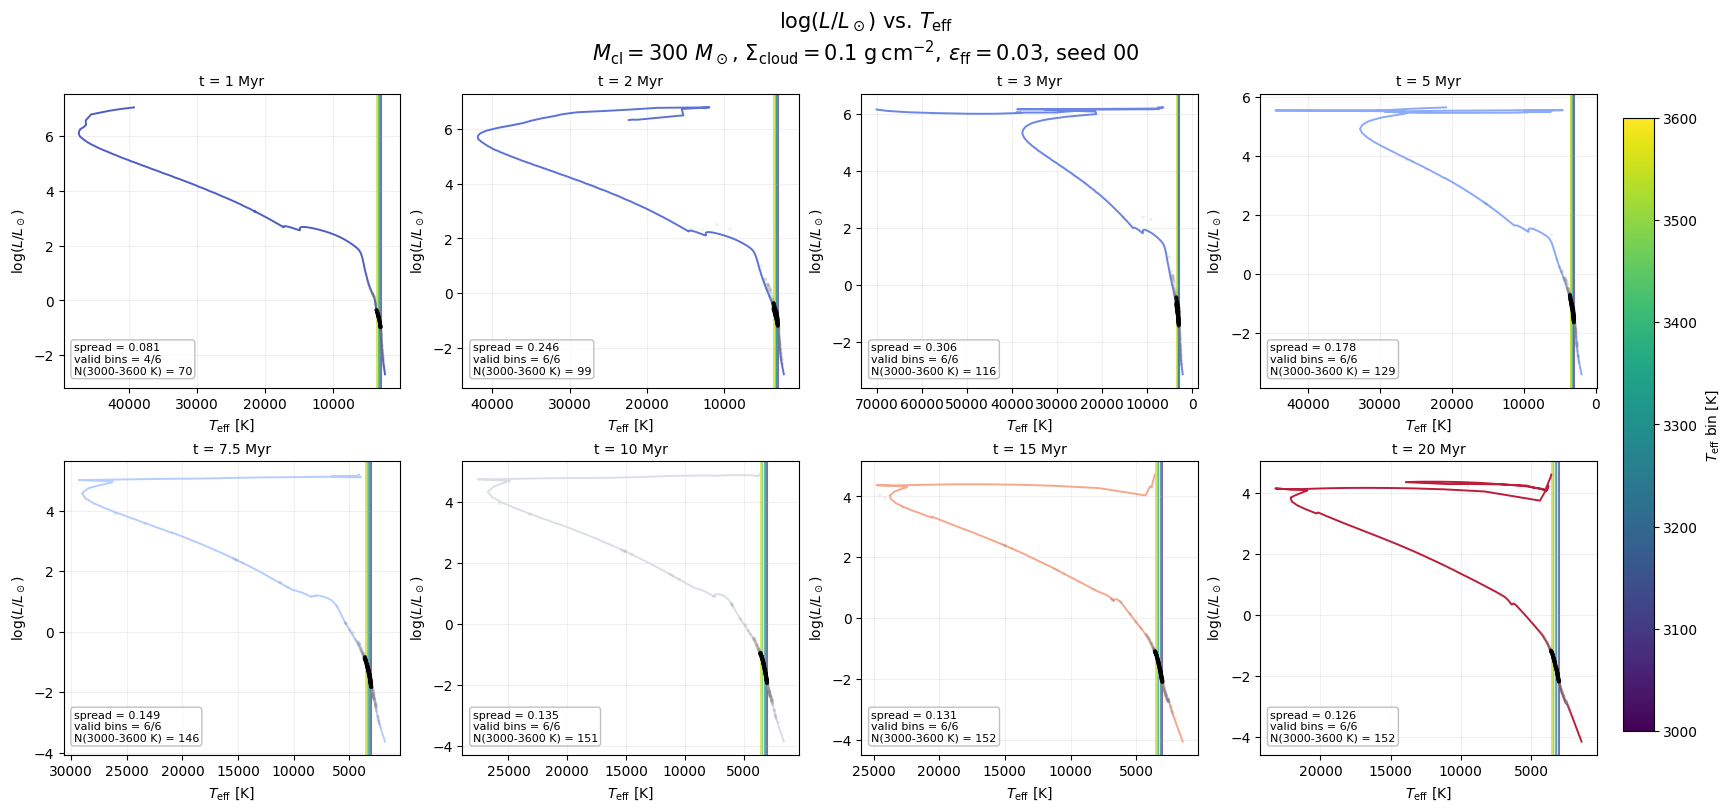

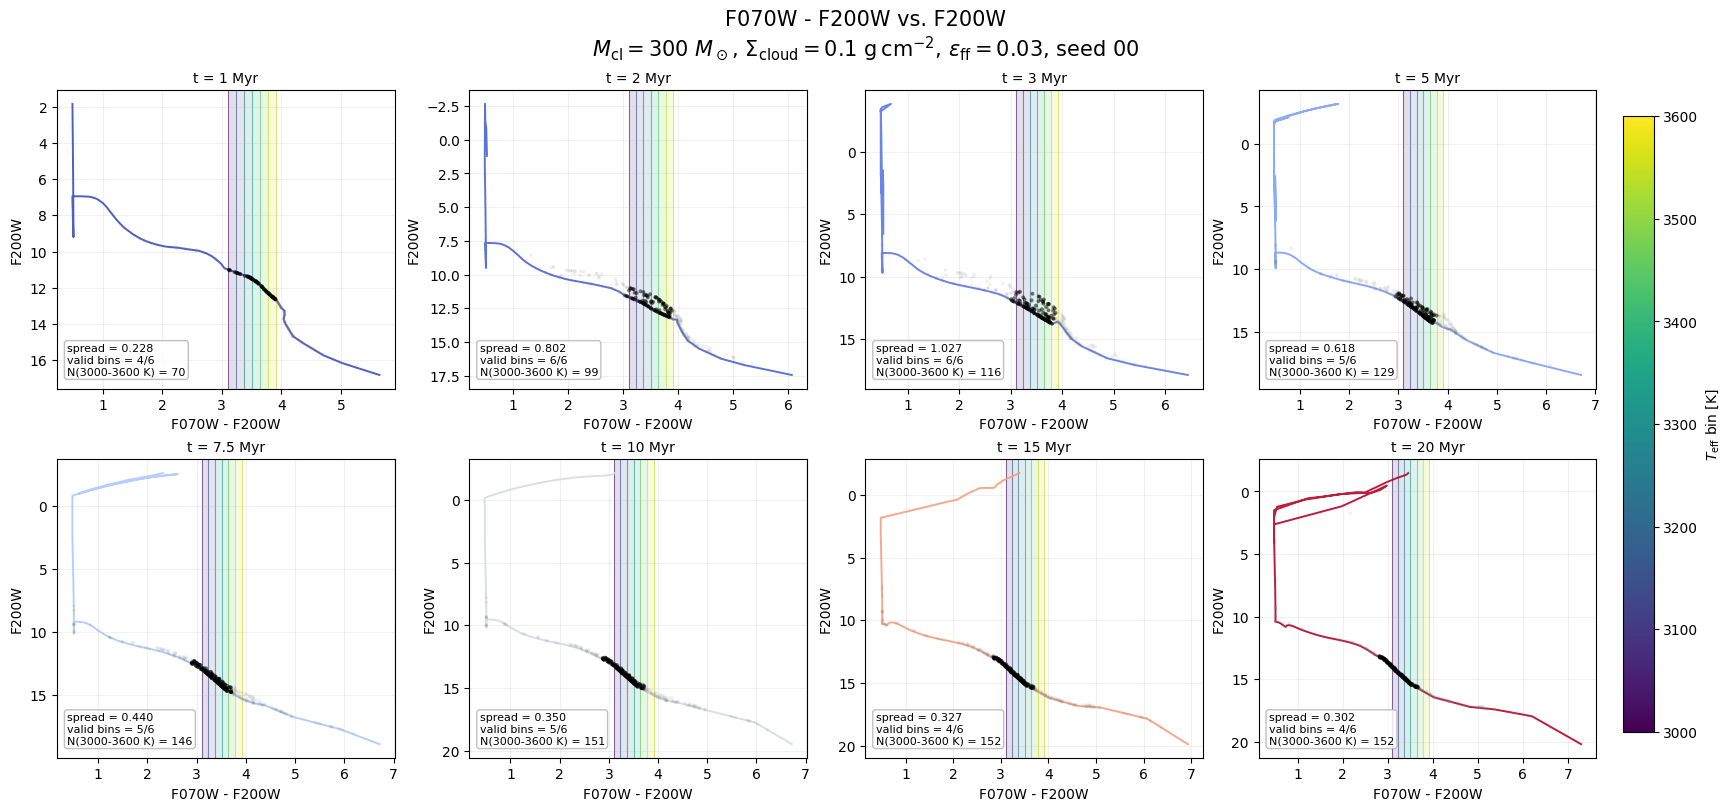

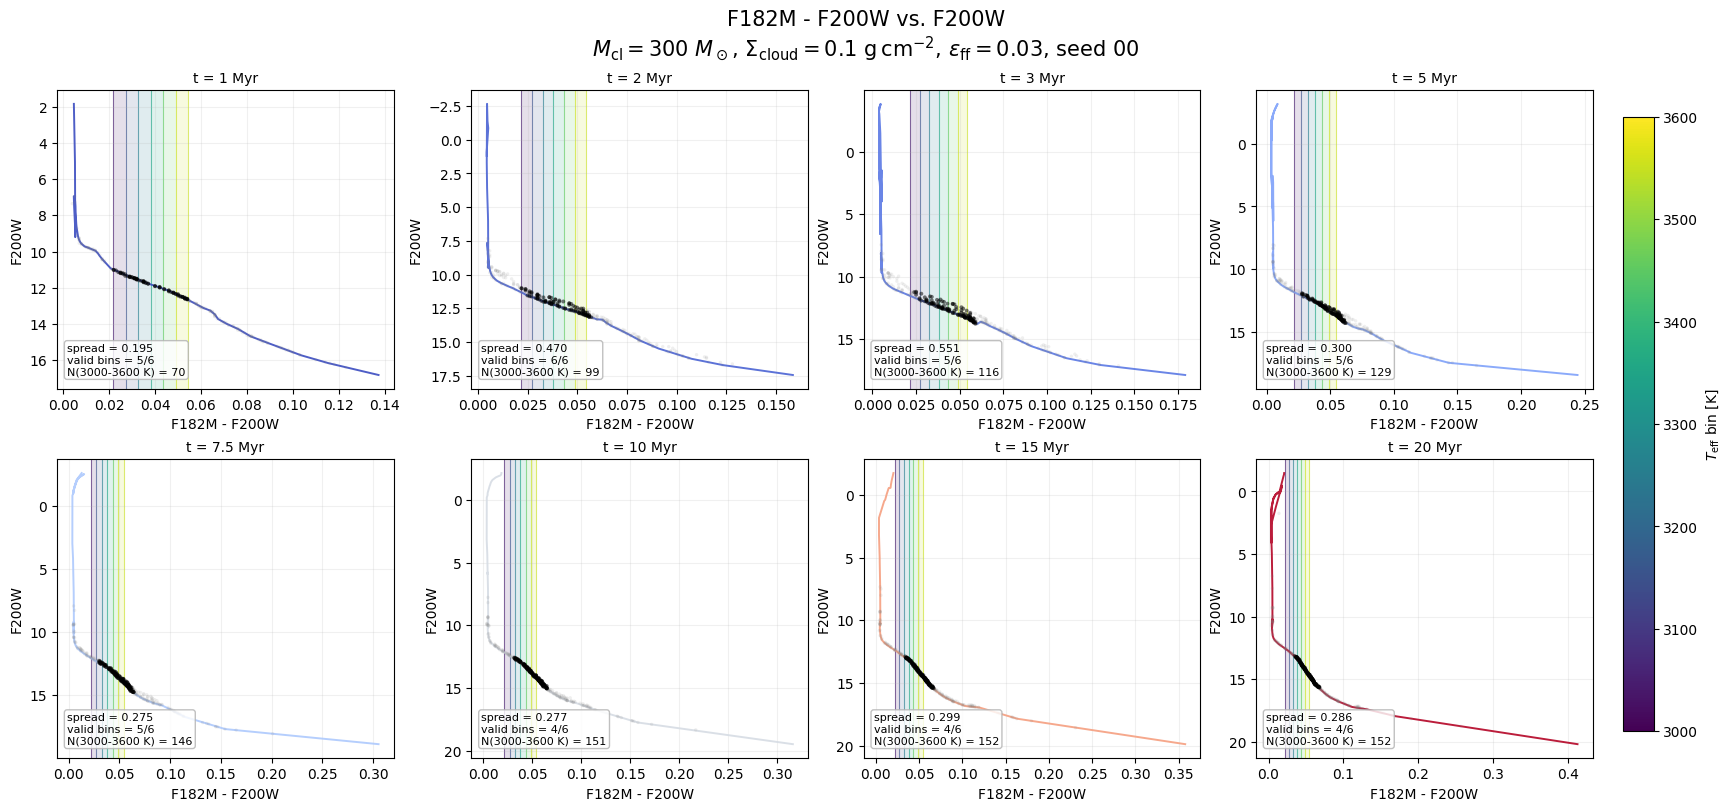

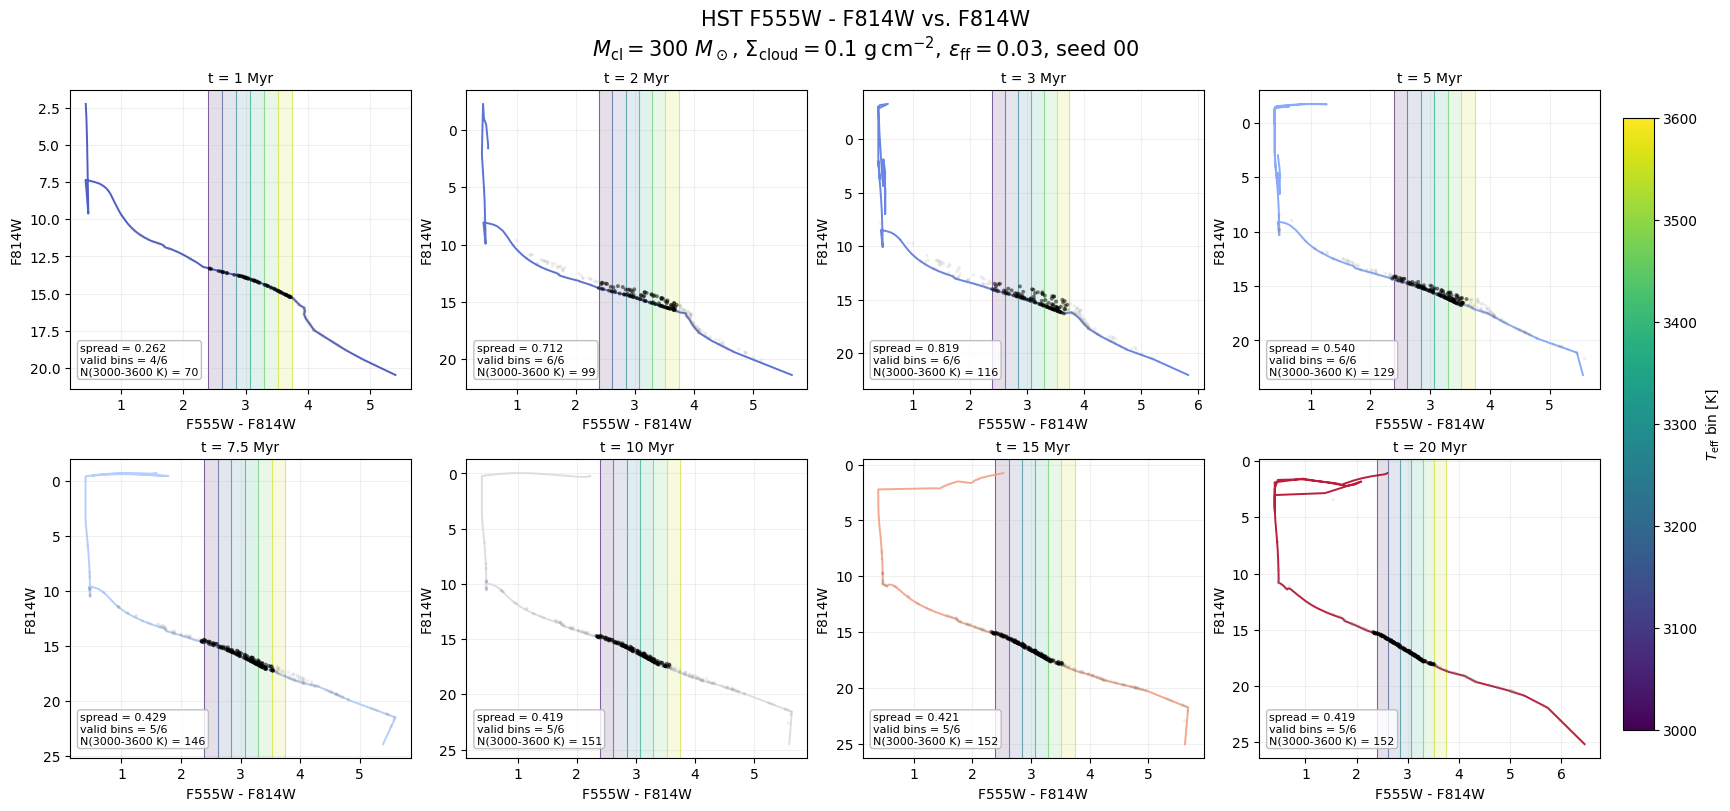

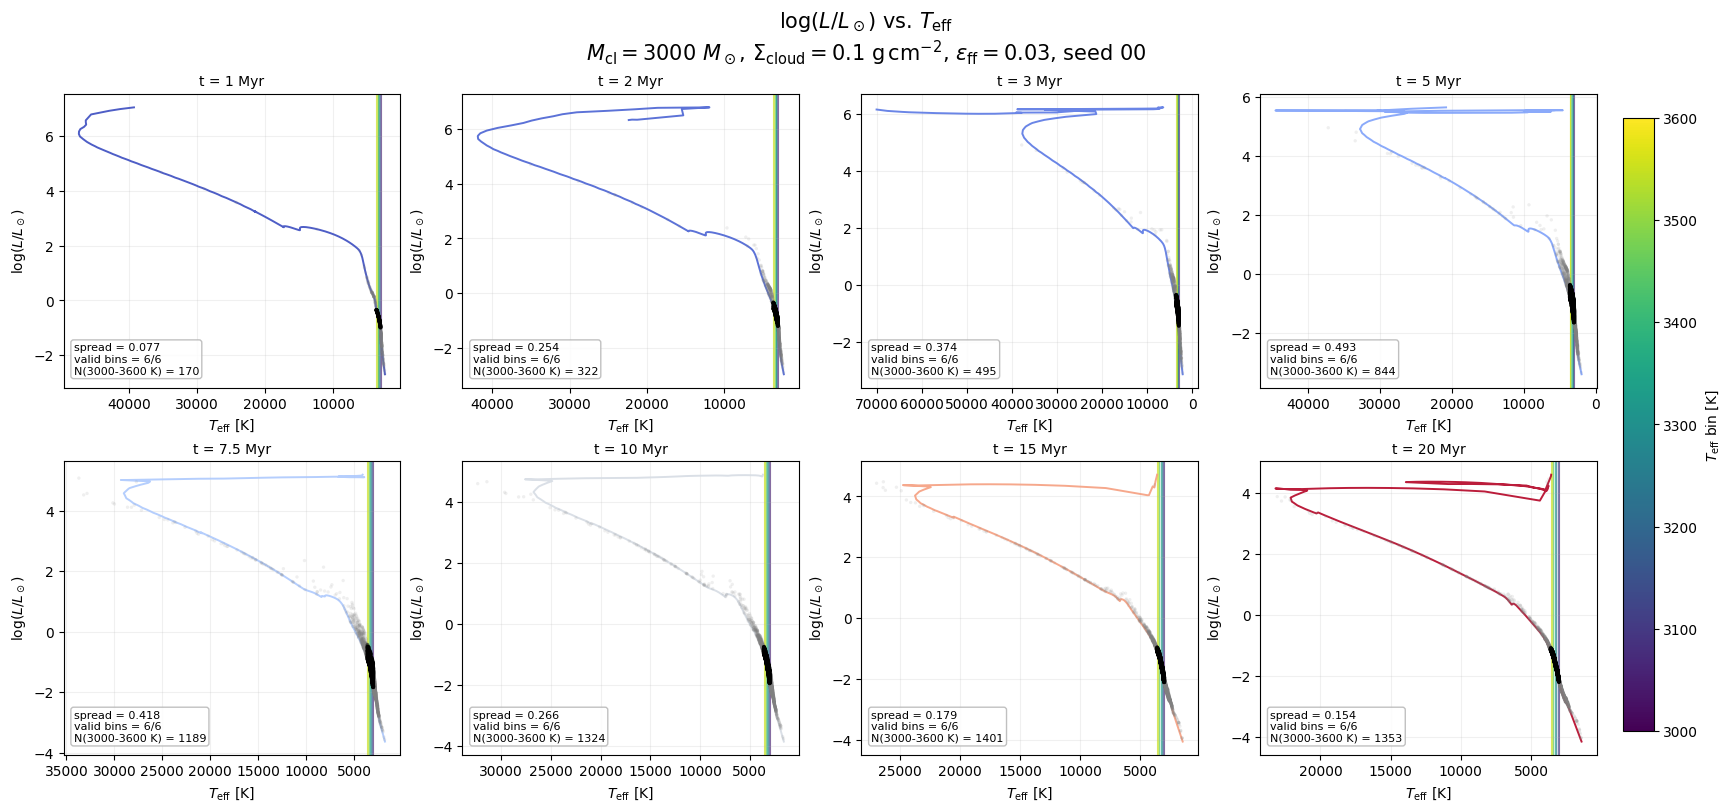

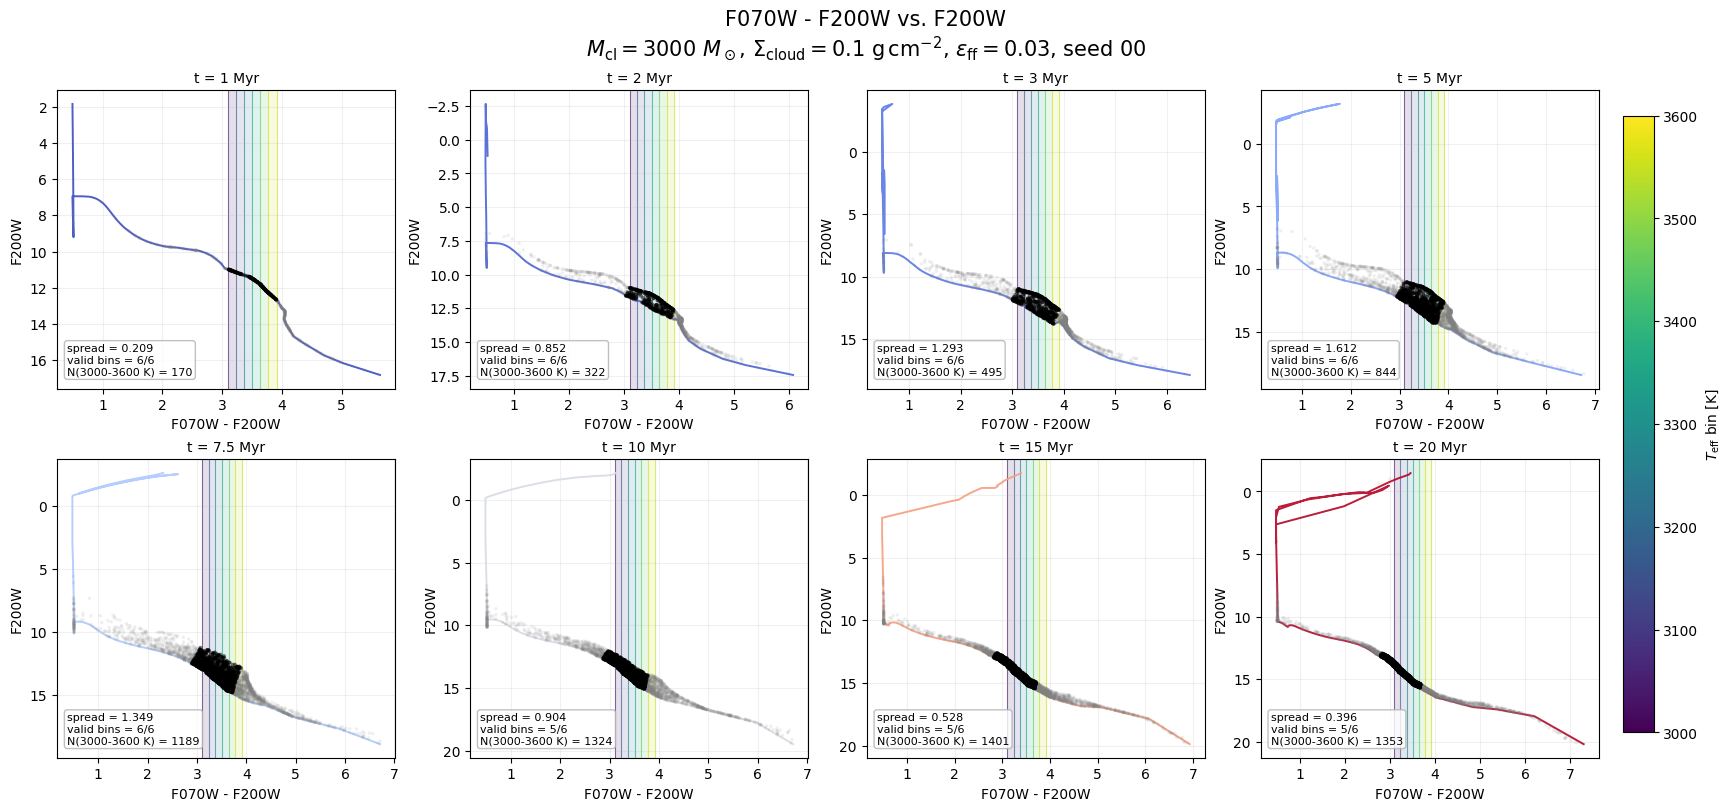

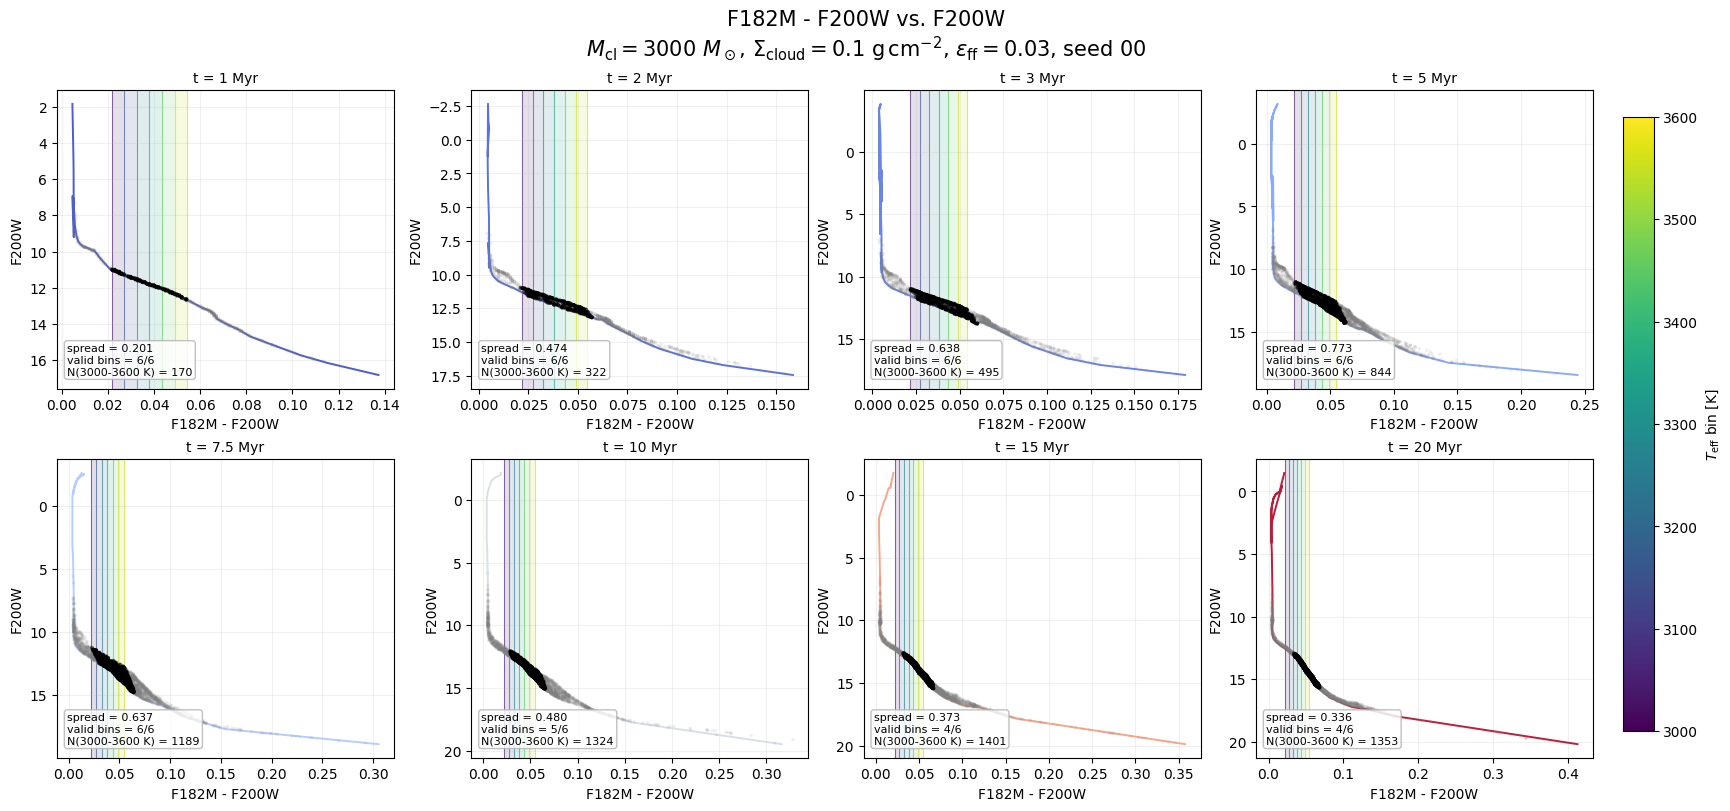

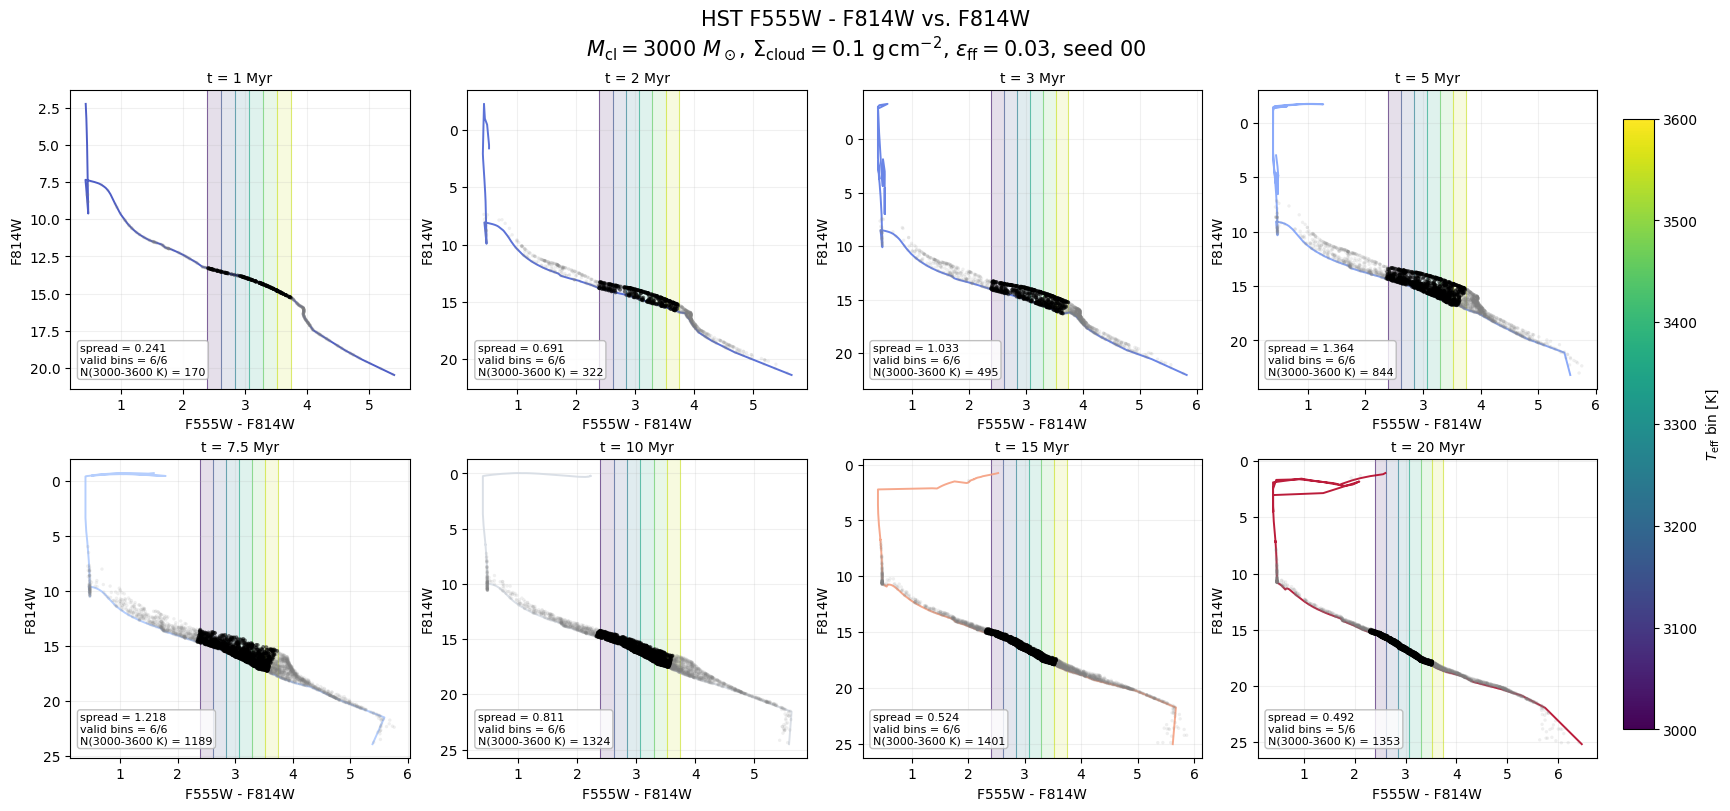

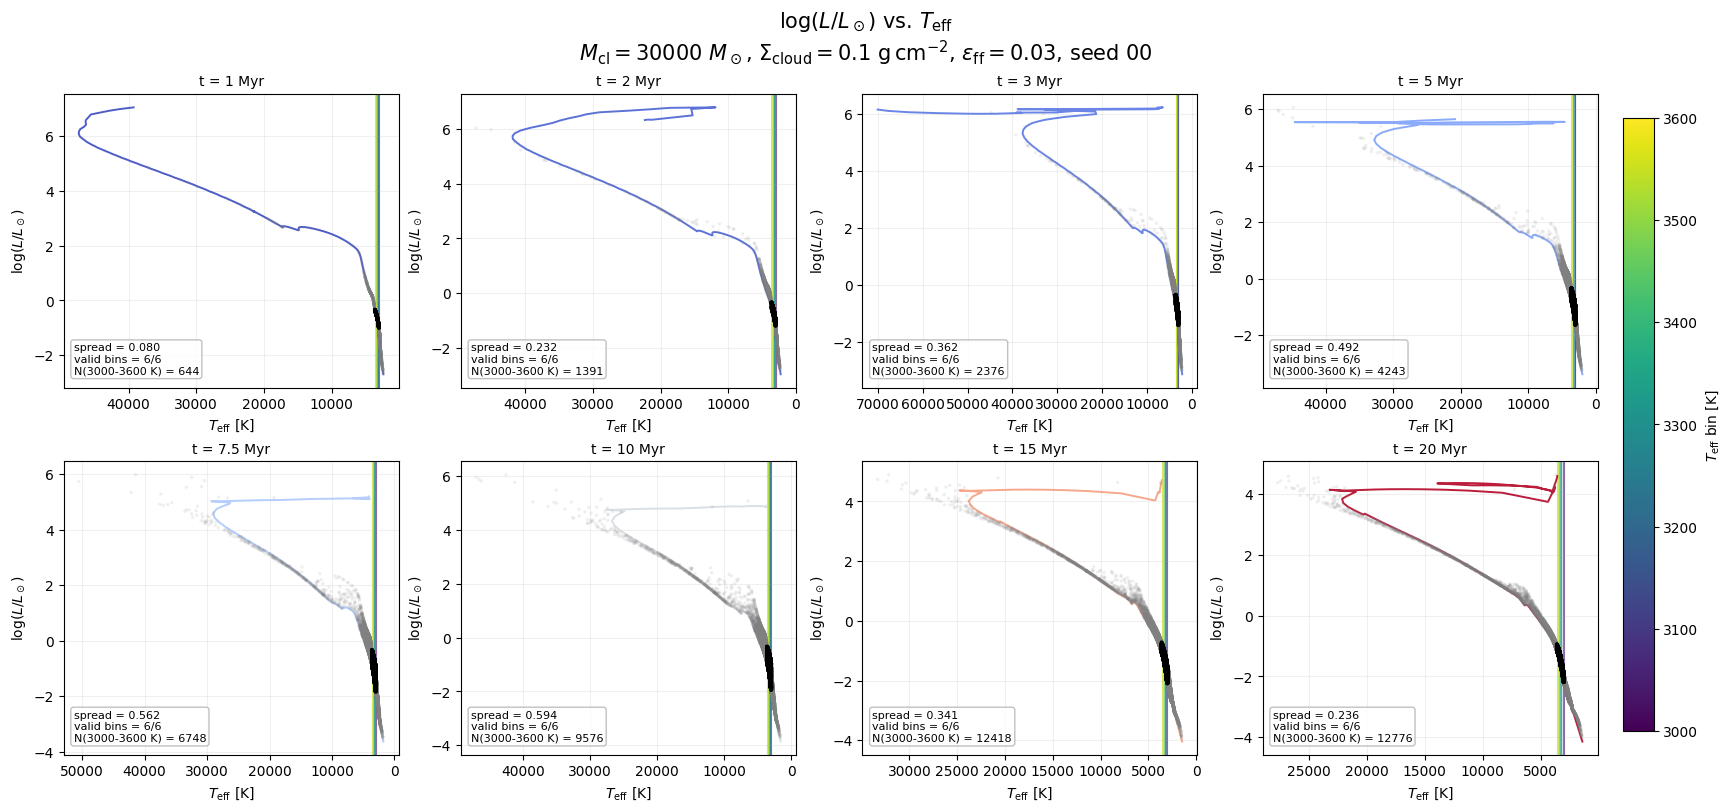

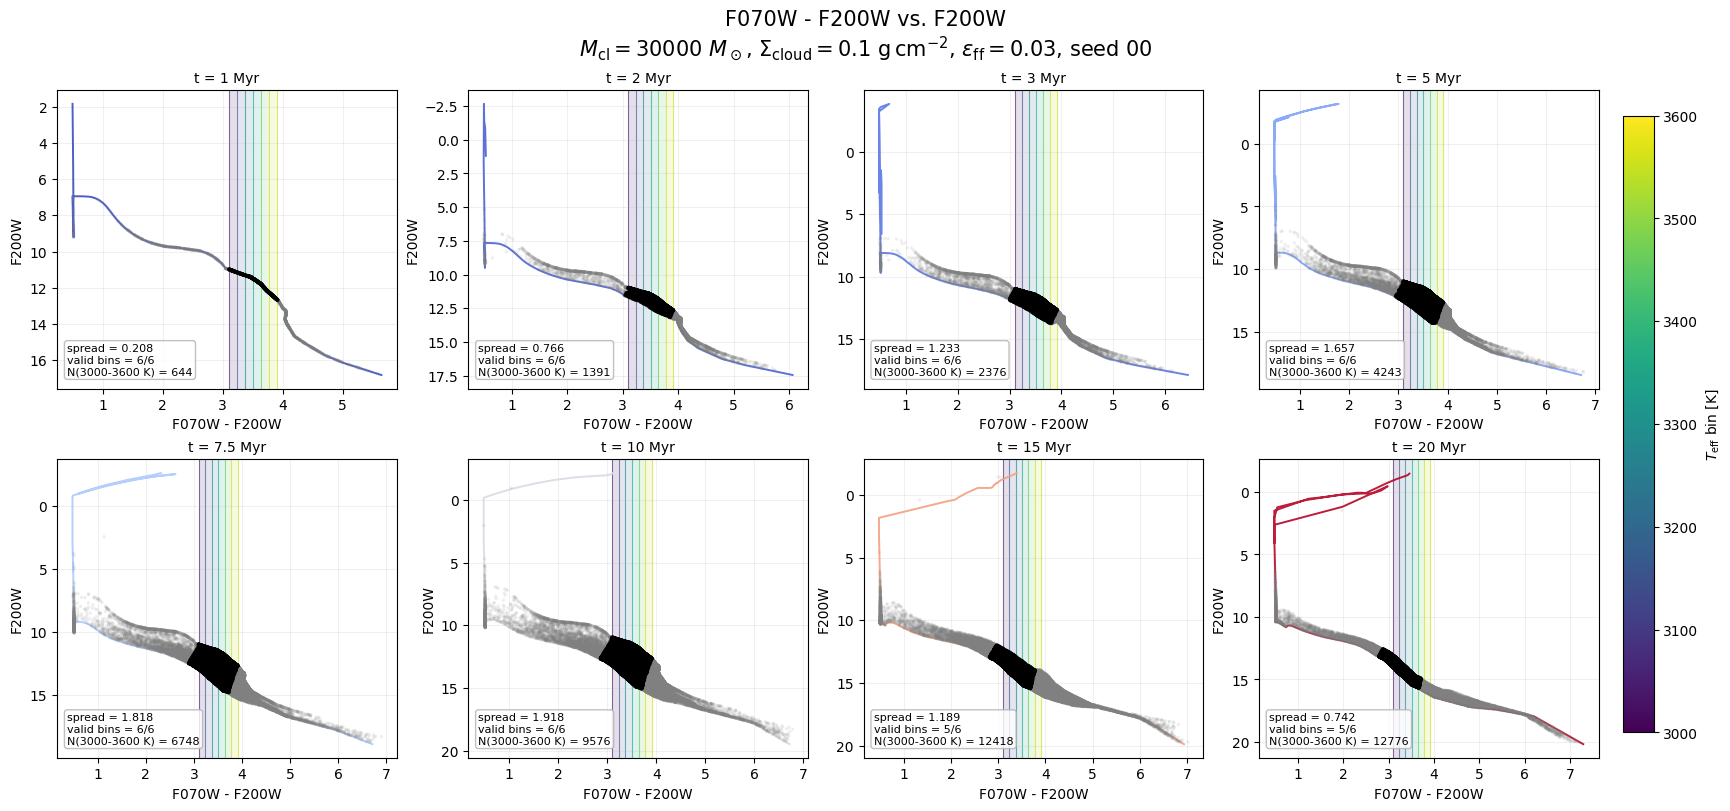

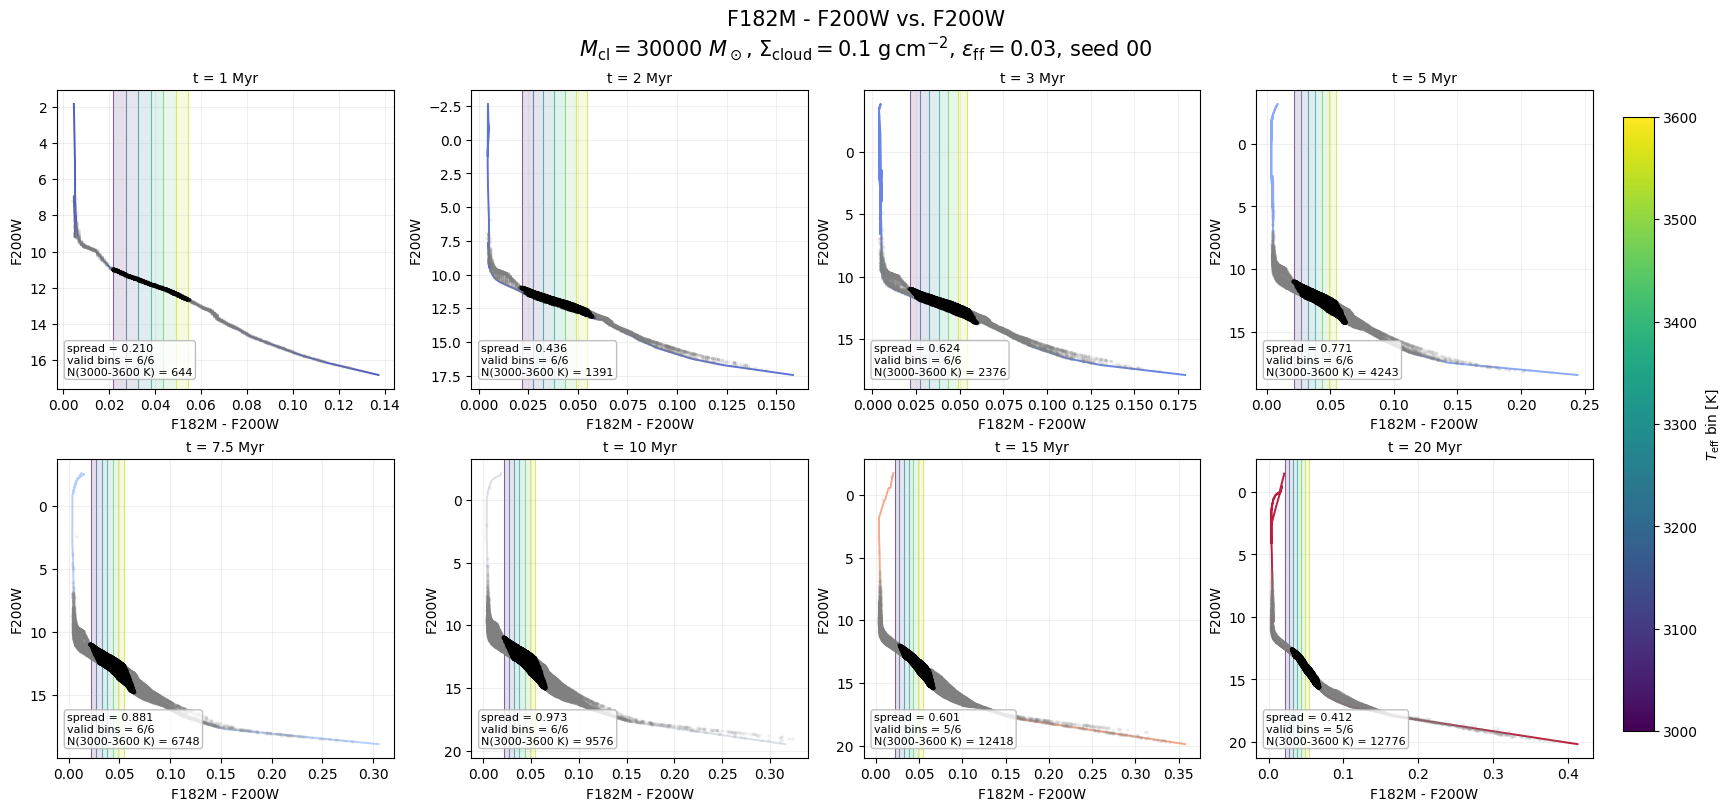

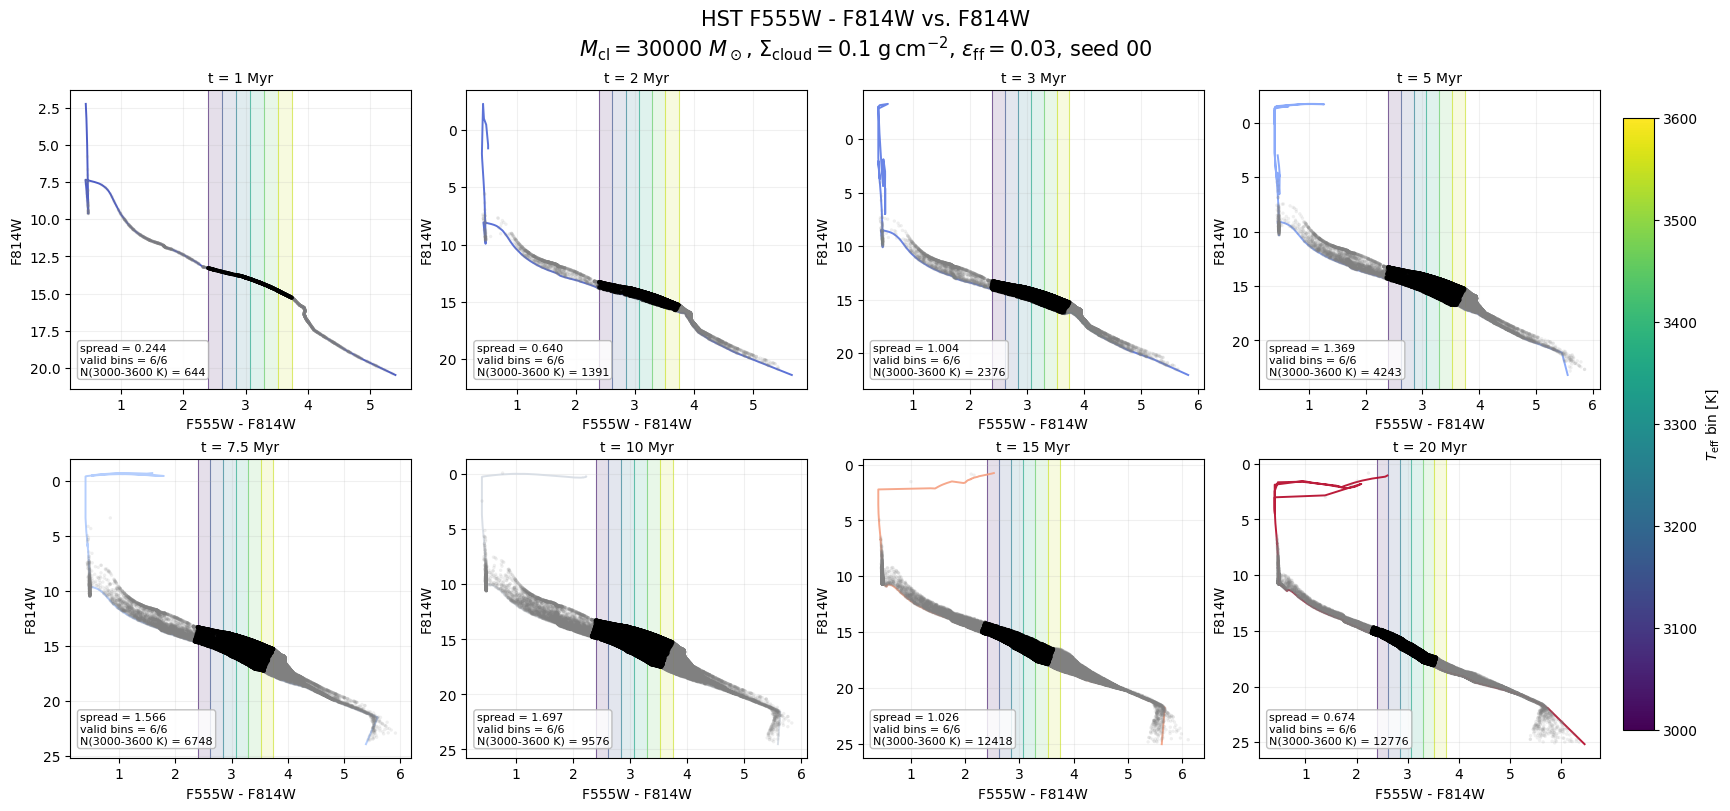

In [13]:
for cluster_mass in SIMULATION_PATHS:
    for diagram in DIAGRAMS:
        times = available_display_times(cluster_mass)
        if not times:
            continue
        ncols = 4
        nrows = int(np.ceil(len(times) / ncols))
        fig, axes = plt.subplots(
            nrows, ncols, figsize=(4.3 * ncols, 4.0 * nrows),
            constrained_layout=True, squeeze=False,
        )
        for ax, t in zip(axes.flat, times):
            plot_snapshot_panel(ax, cluster_mass, t, diagram)
        for ax in axes.flat[len(times):]:
            ax.set_visible(False)

        mappable = ScalarMappable(
            norm=Normalize(TEFF_MIN_K, TEFF_MAX_K), cmap=BIN_CMAP
        )
        mappable.set_array(HR_TEFF_BIN_EDGES_K)
        cbar = fig.colorbar(
            mappable,
            ax=[ax for ax in axes.flat if ax.get_visible()],
            fraction=0.02, pad=0.015,
        )
        cbar.set_label(r'$T_{\rm eff}$ bin [K]')
        cbar.set_ticks(HR_TEFF_BIN_EDGES_K)
        fig.suptitle(
            diagram.title + '\n'
            + rf'$M_{{\rm cl}}={cluster_mass:g}\ M_\odot$, '
            + rf'$\Sigma_{{\rm cloud}}={SIGMA_CLOUD:g}\ {{\rm g\,cm^{{-2}}}}$, '
            + rf'$\epsilon_{{\rm ff}}={EPSILON_FF:g}$, seed {SEED}',
            fontsize=15,
        )
        finish_figure(fig, f'time_evolution_{mass_tag(cluster_mass)}_{diagram.key}.png')

## Same-age side-by-side mass comparisons

For each diagram, rows are time and columns are M_cl=300, 3000, 30000.

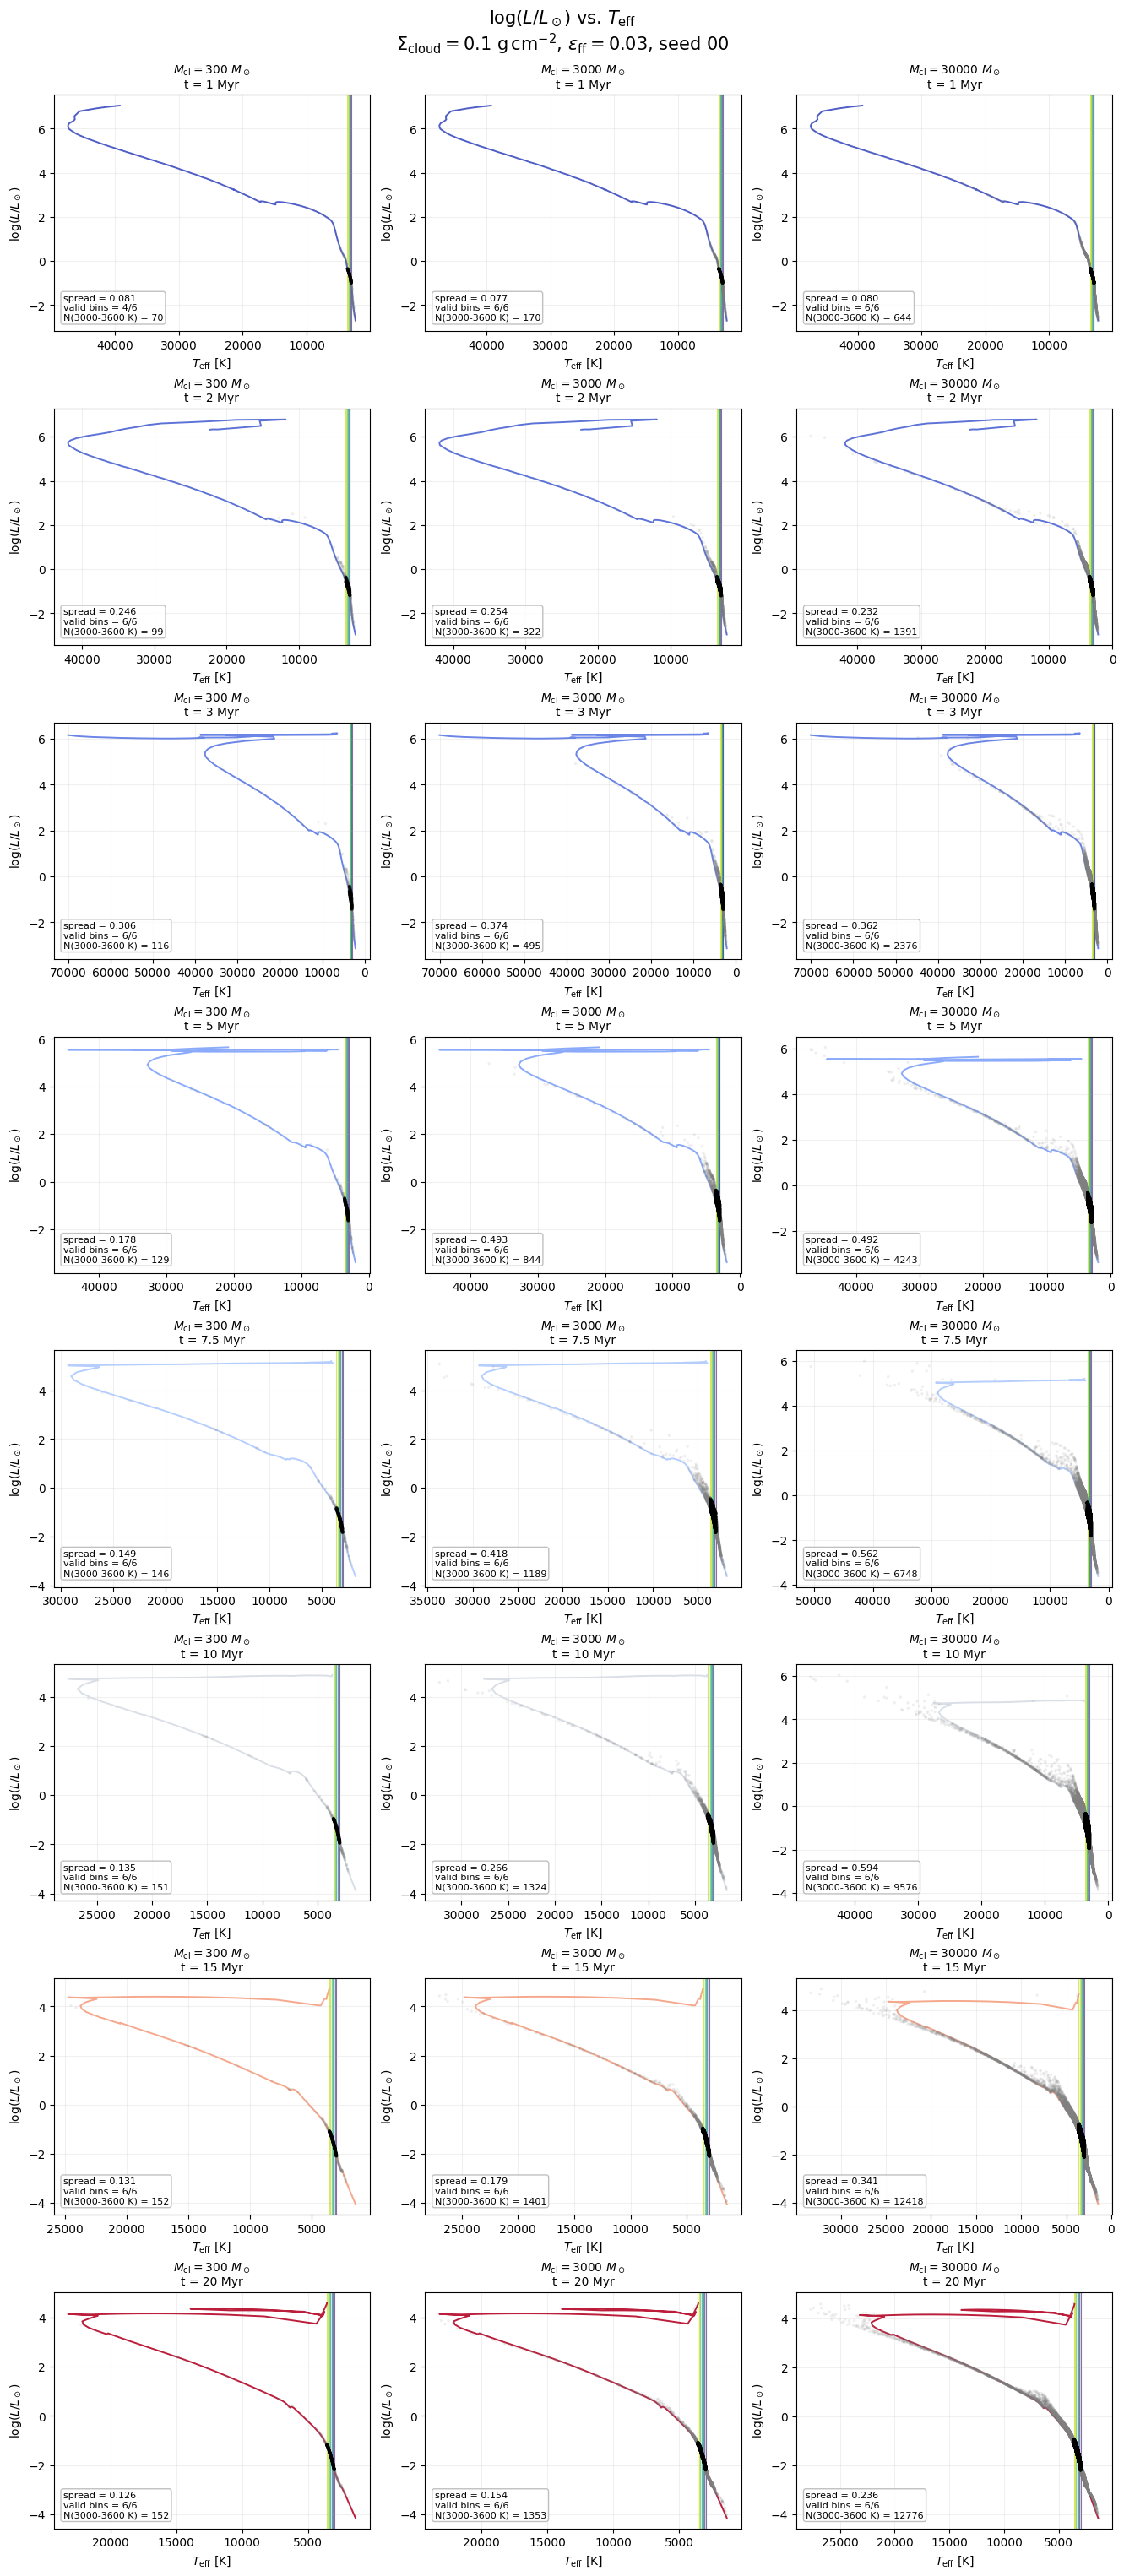

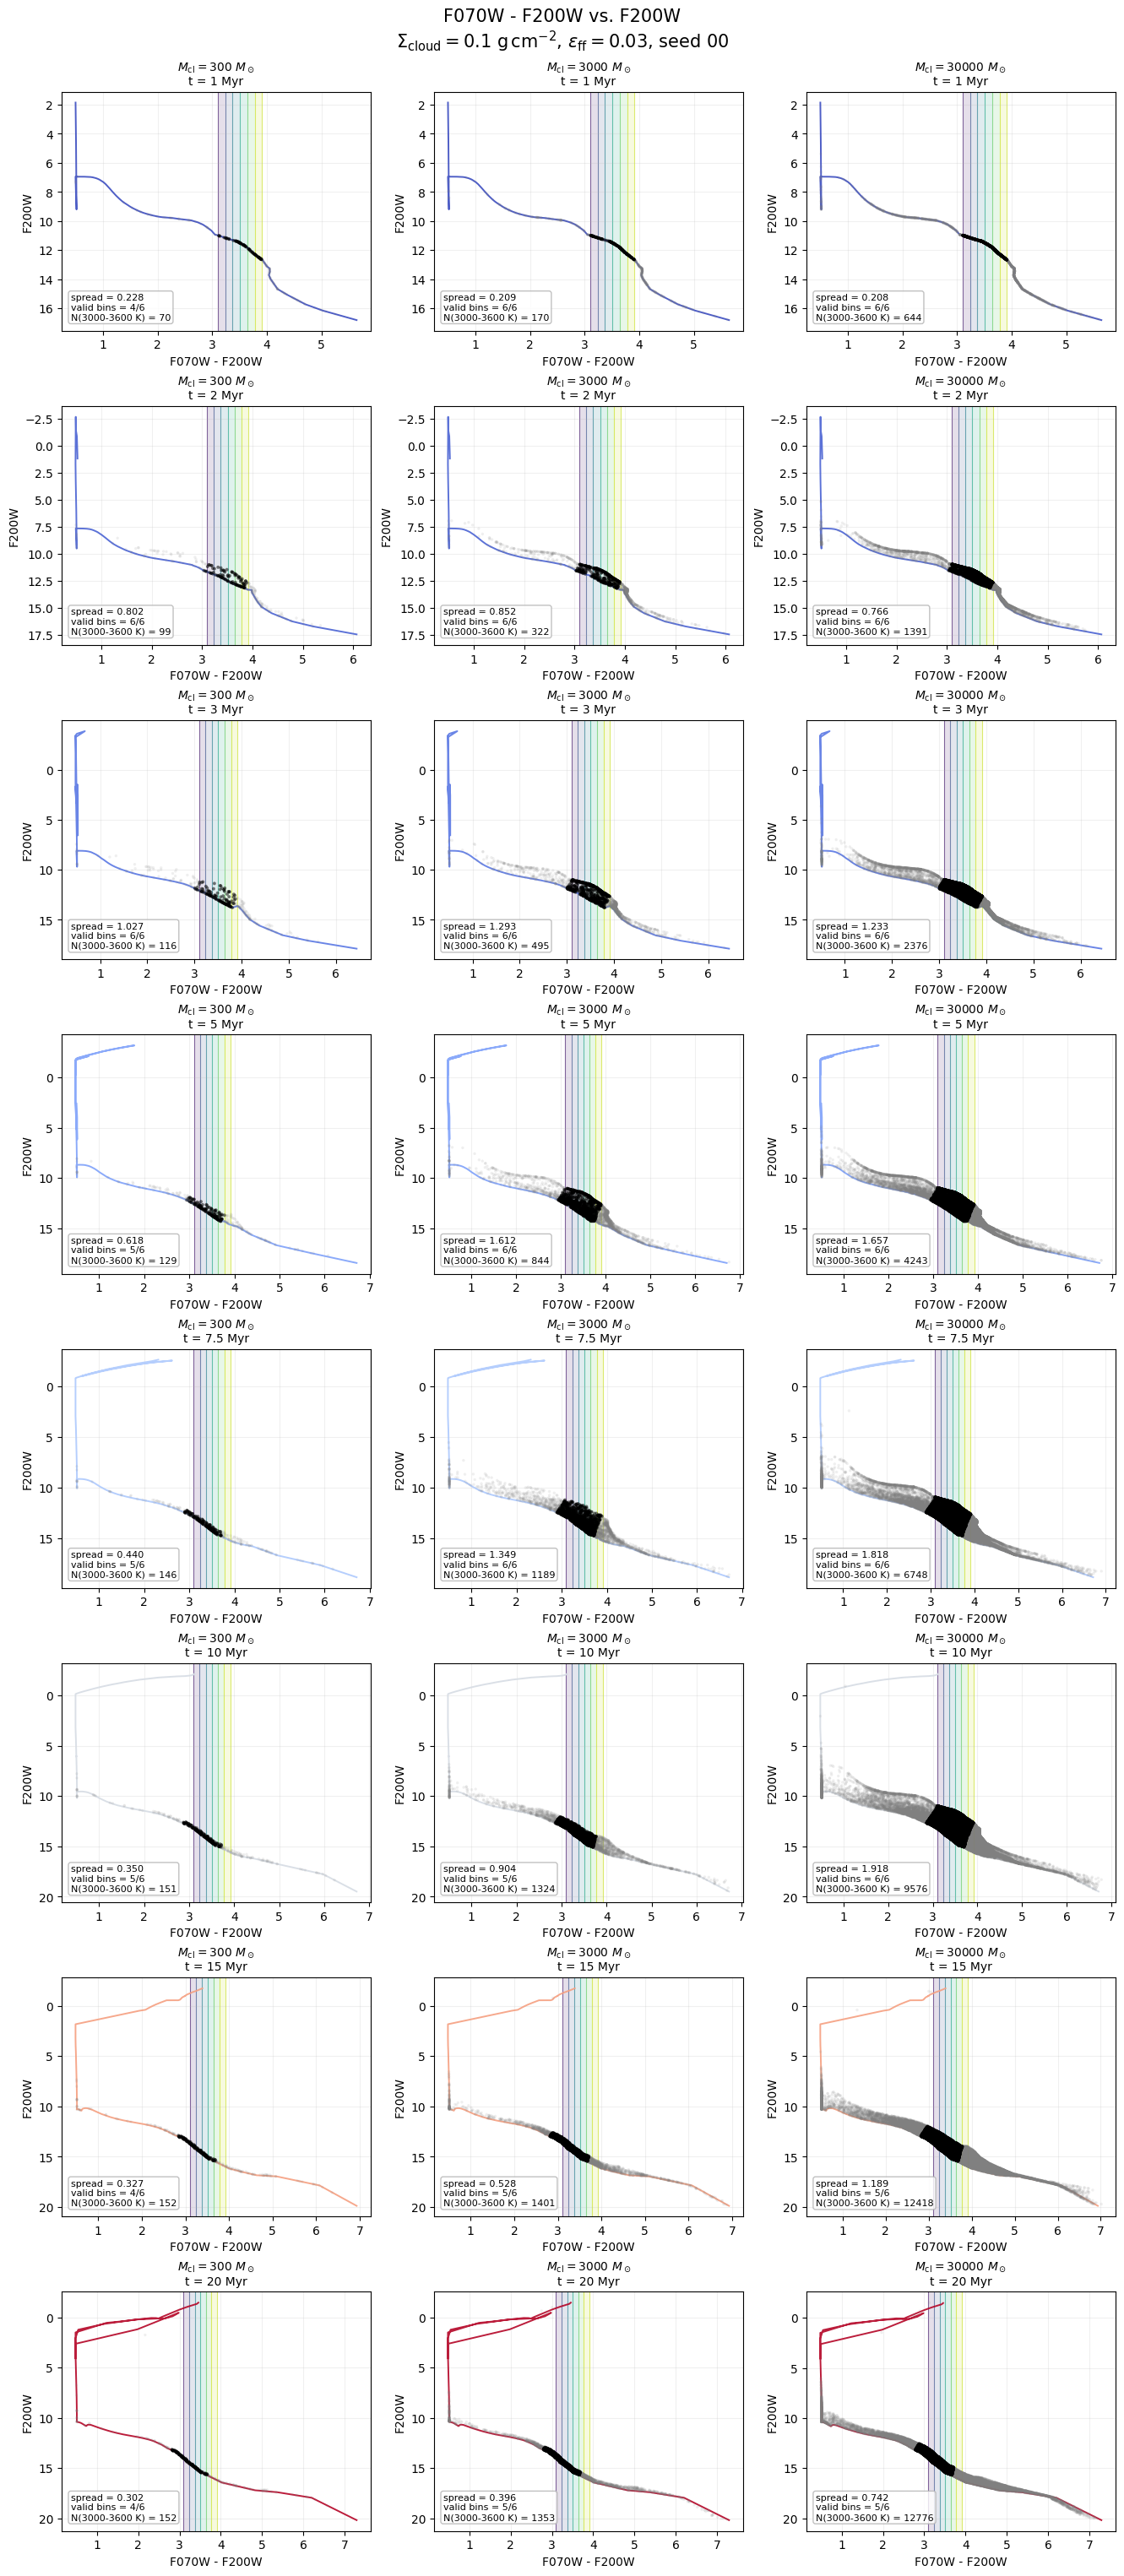

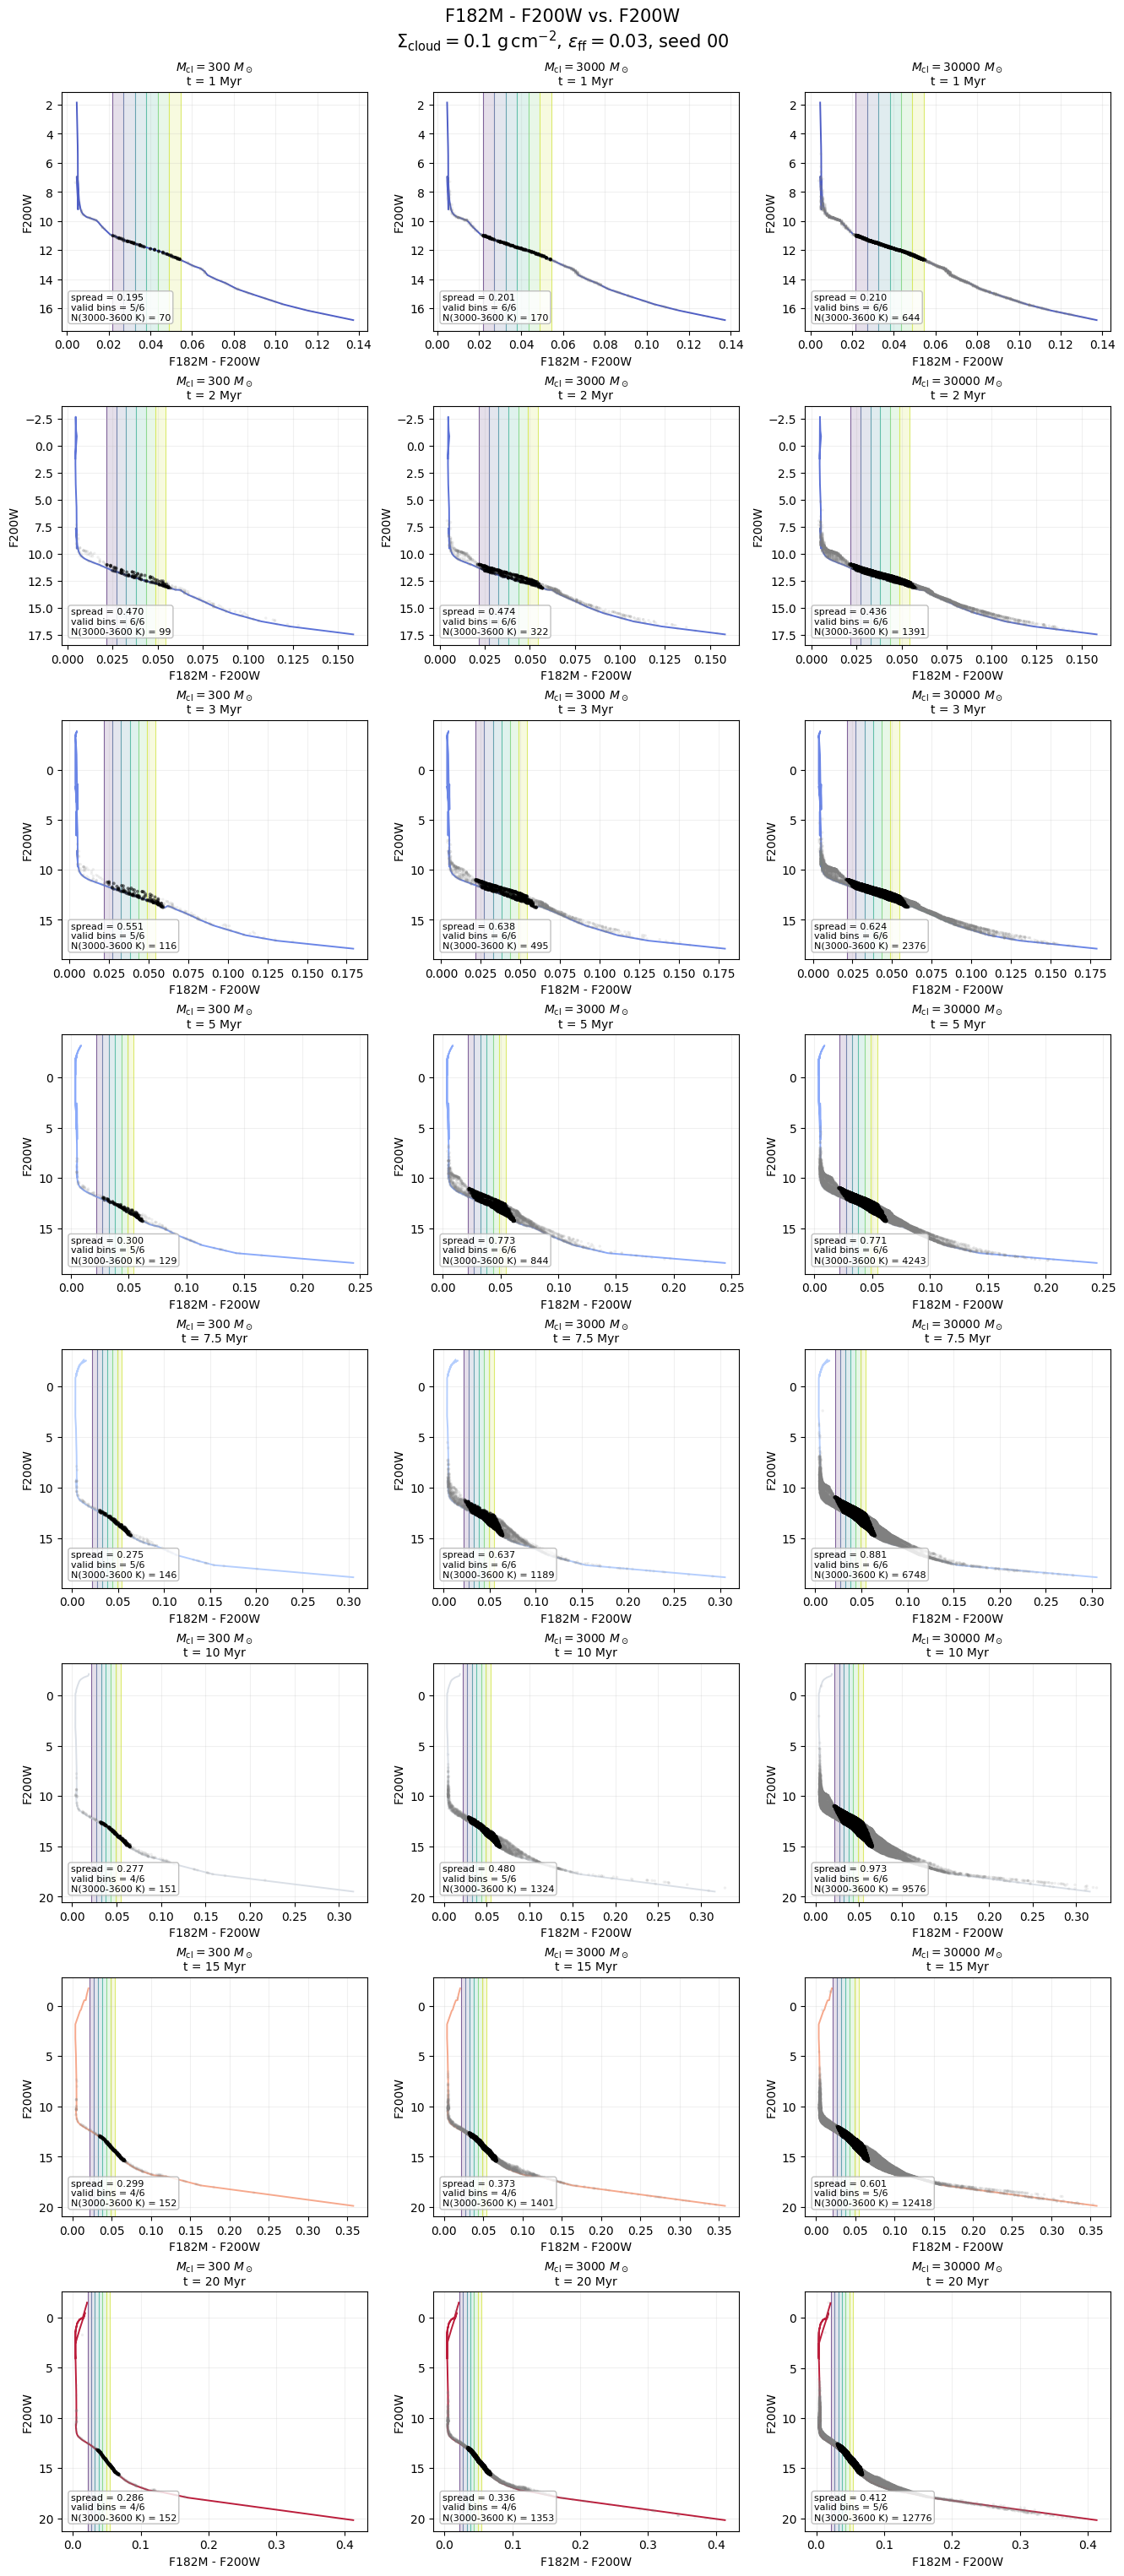

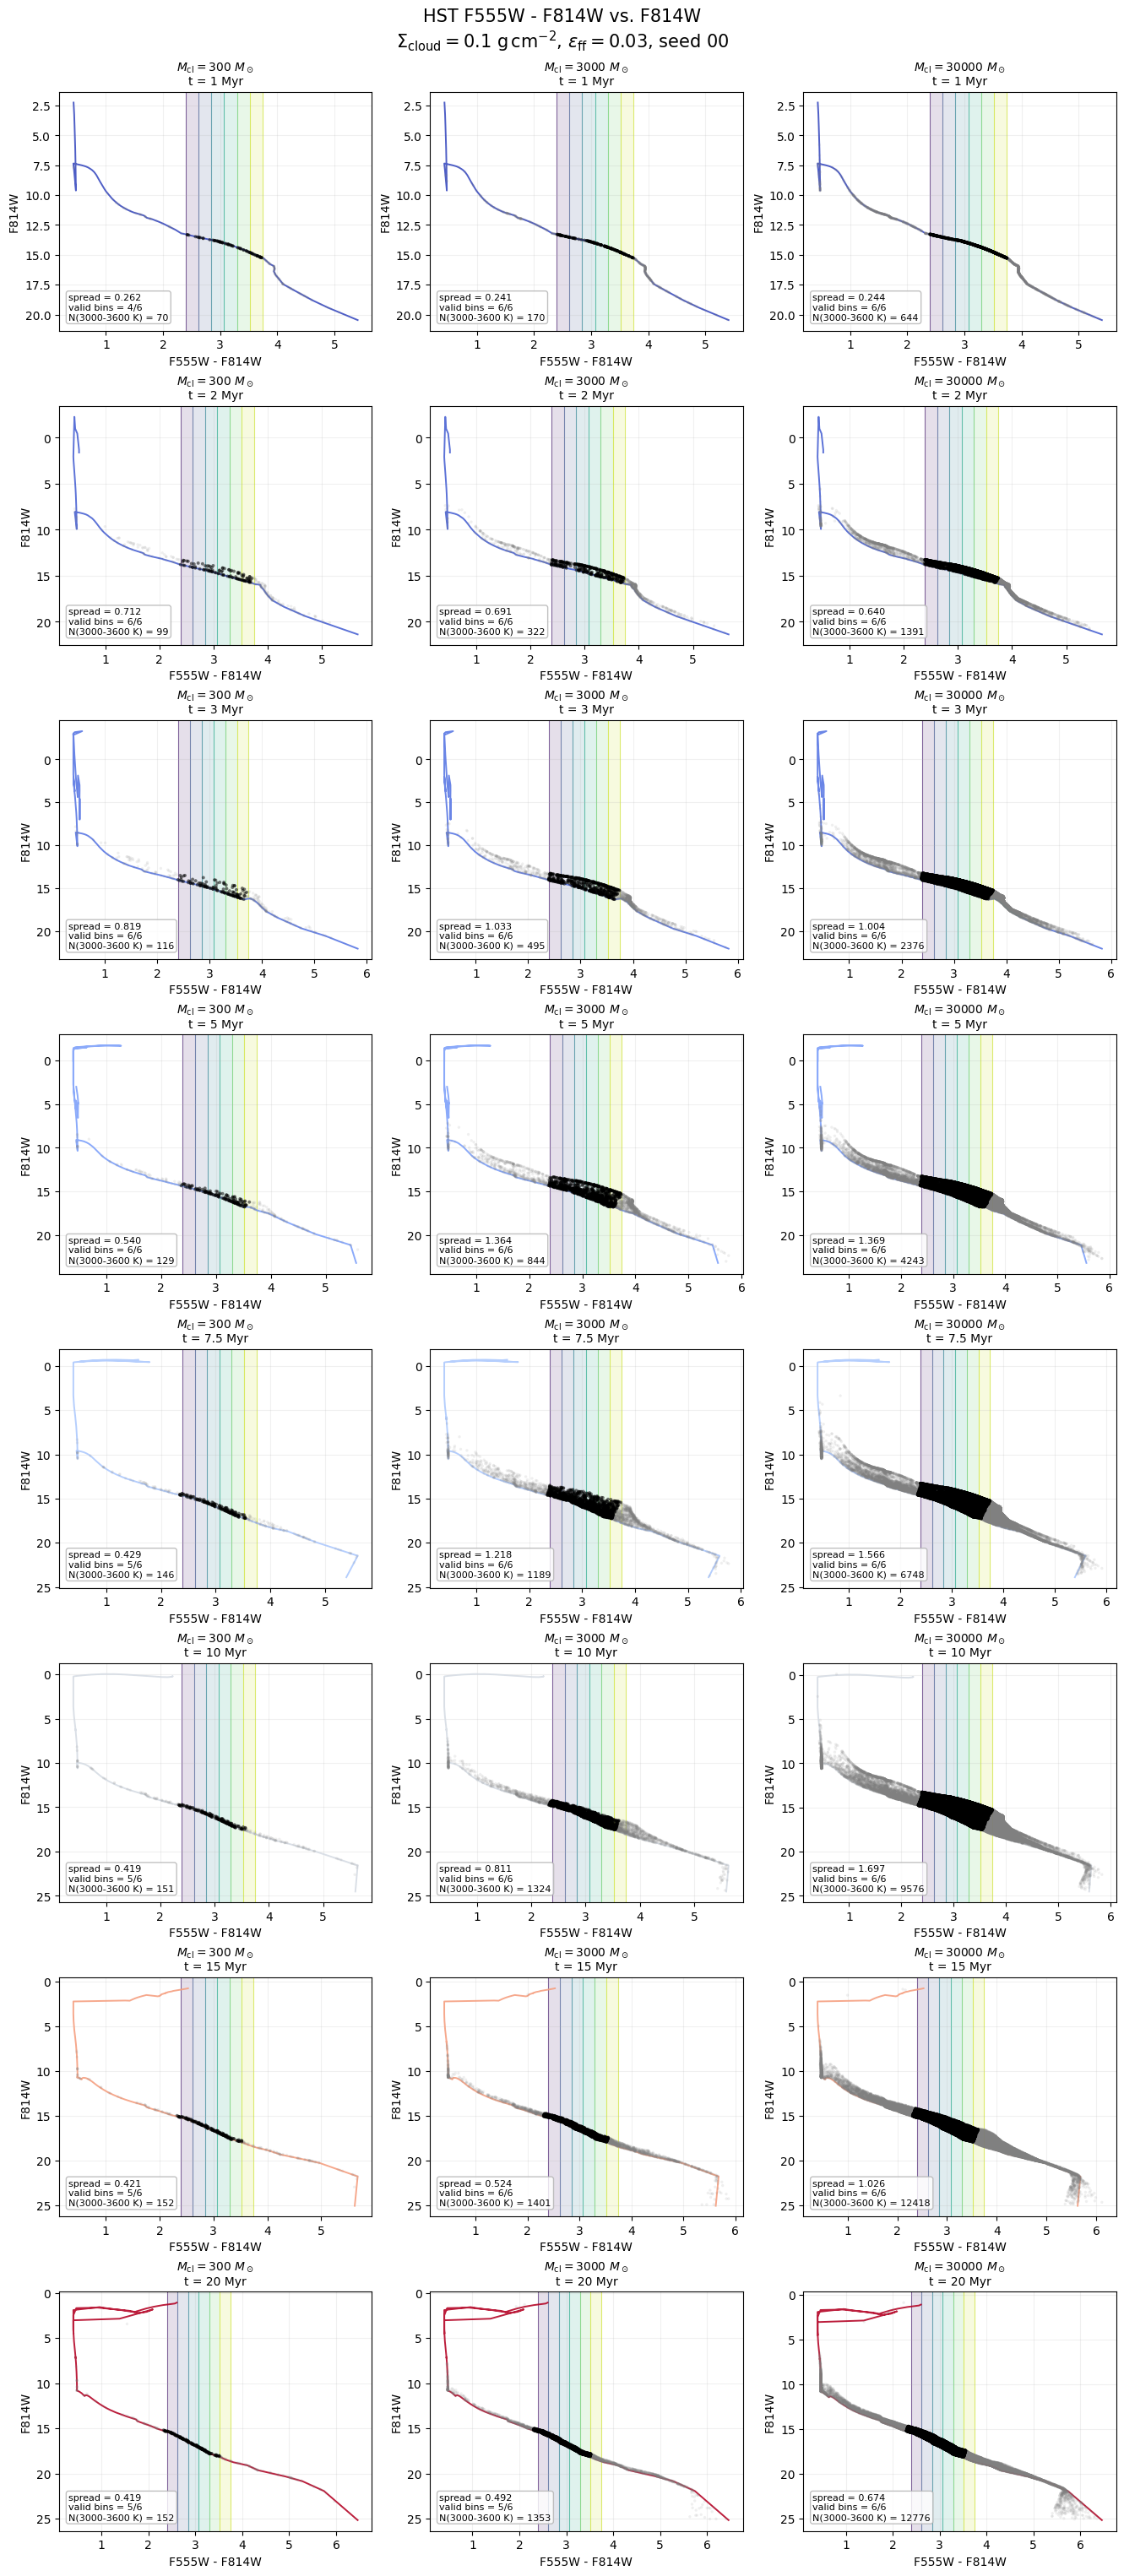

In [14]:
for diagram in DIAGRAMS:
    times = [
        float(t) for t in DISPLAY_TIMES_MYR
        if all(
            (int(m), float(t)) in catalogs
            and not catalogs[(int(m), float(t))].empty
            for m in SIMULATION_PATHS
        )
    ]
    if not times:
        continue
    masses = list(SIMULATION_PATHS)
    fig, axes = plt.subplots(
        len(times), len(masses),
        figsize=(4.4 * len(masses), 3.8 * len(times)),
        constrained_layout=True, squeeze=False,
    )
    for r, t in enumerate(times):
        for c, m in enumerate(masses):
            plot_snapshot_panel(axes[r, c], m, t, diagram)
            axes[r, c].set_title(
                rf'$M_{{\rm cl}}={m:g}\ M_\odot$' + f'\nt = {t:g} Myr',
                fontsize=10,
            )
    fig.suptitle(
        diagram.title + '\n'
        + rf'$\Sigma_{{\rm cloud}}={SIGMA_CLOUD:g}\ {{\rm g\,cm^{{-2}}}}$, '
        + rf'$\epsilon_{{\rm ff}}={EPSILON_FF:g}$, seed {SEED}',
        fontsize=15,
    )
    finish_figure(fig, f'mass_snapshot_comparison_{diagram.key}.png')

## Spread-metric evolution by cluster mass

No averaging or error bars are used: this is one seed per cluster mass.

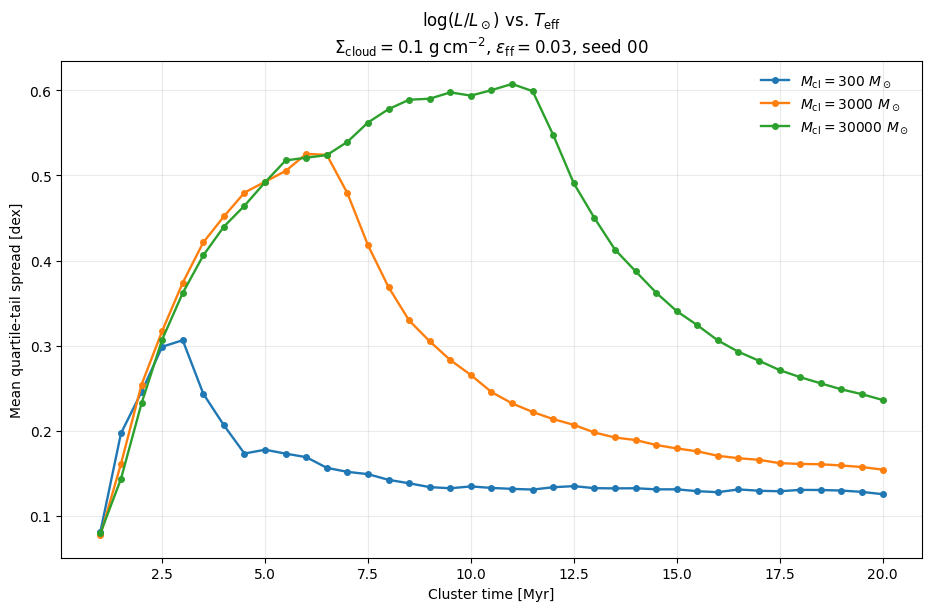

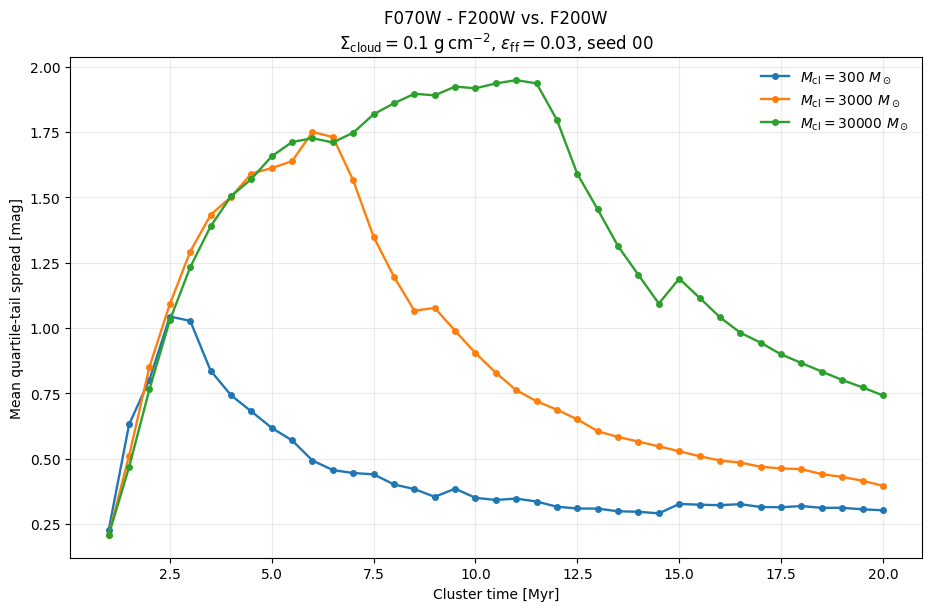

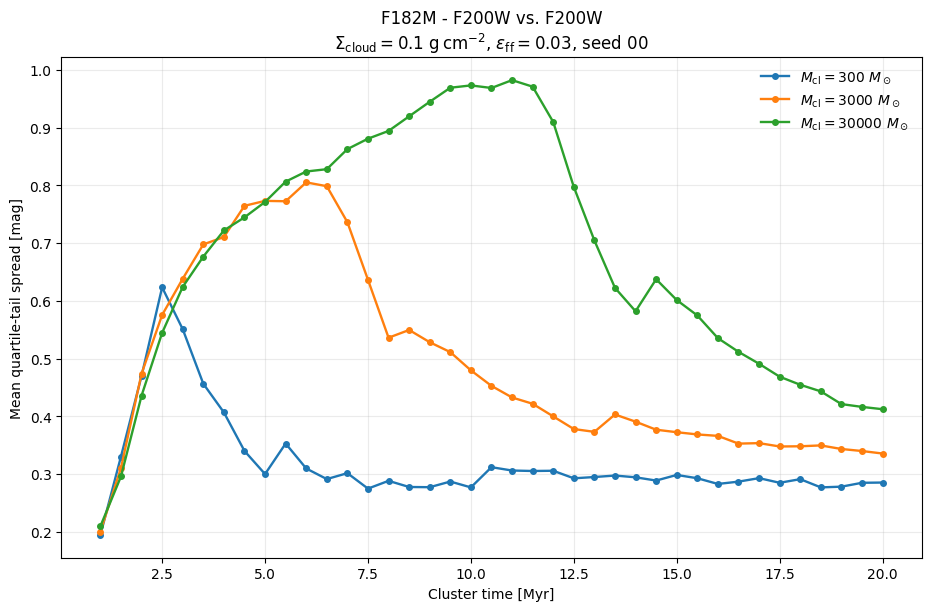

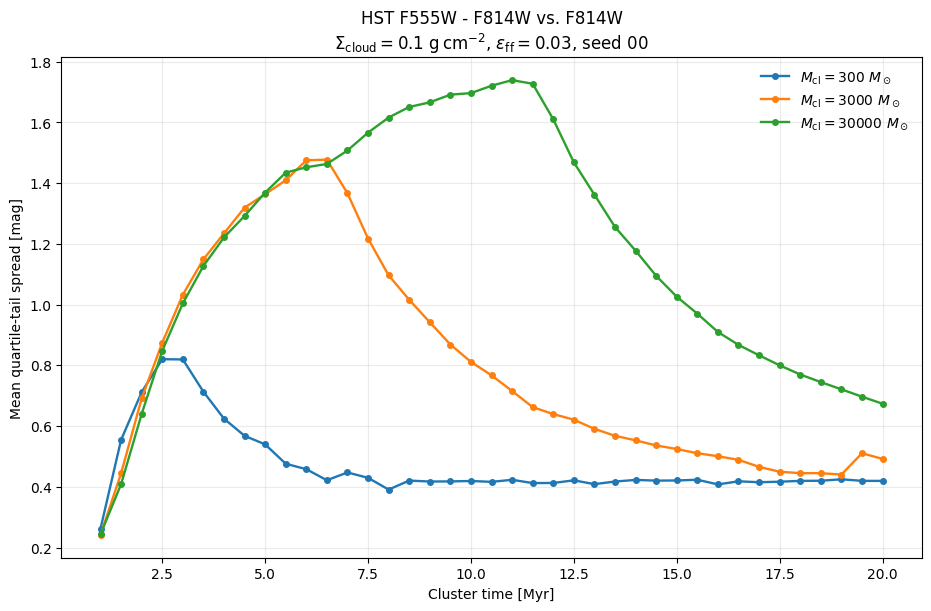

In [15]:
for diagram in DIAGRAMS:
    fig, ax = plt.subplots(figsize=(9.2, 6.0), constrained_layout=True)
    for cluster_mass in SIMULATION_PATHS:
        sub = df_metrics[
            (df_metrics['cluster_mass_msun'] == int(cluster_mass))
            & (df_metrics['diagram'] == diagram.key)
        ].sort_values('snapshot_time_myr')
        if sub.empty:
            continue
        ax.plot(
            sub['snapshot_time_myr'], sub['spread_metric'],
            marker='o', ms=4, lw=1.7,
            label=rf'$M_{{\rm cl}}={cluster_mass:g}\ M_\odot$',
        )
    ax.set_xlabel('Cluster time [Myr]')
    ax.set_ylabel(f'Mean quartile-tail spread [{diagram_unit(diagram)}]')
    ax.set_title(
        diagram.title + '\n'
        + rf'$\Sigma_{{\rm cloud}}={SIGMA_CLOUD:g}\ {{\rm g\,cm^{{-2}}}}$, '
        + rf'$\epsilon_{{\rm ff}}={EPSILON_FF:g}$, seed {SEED}'
    )
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    finish_figure(fig, f'spread_by_cluster_mass_{diagram.key}.png')

## Four-panel spread overview

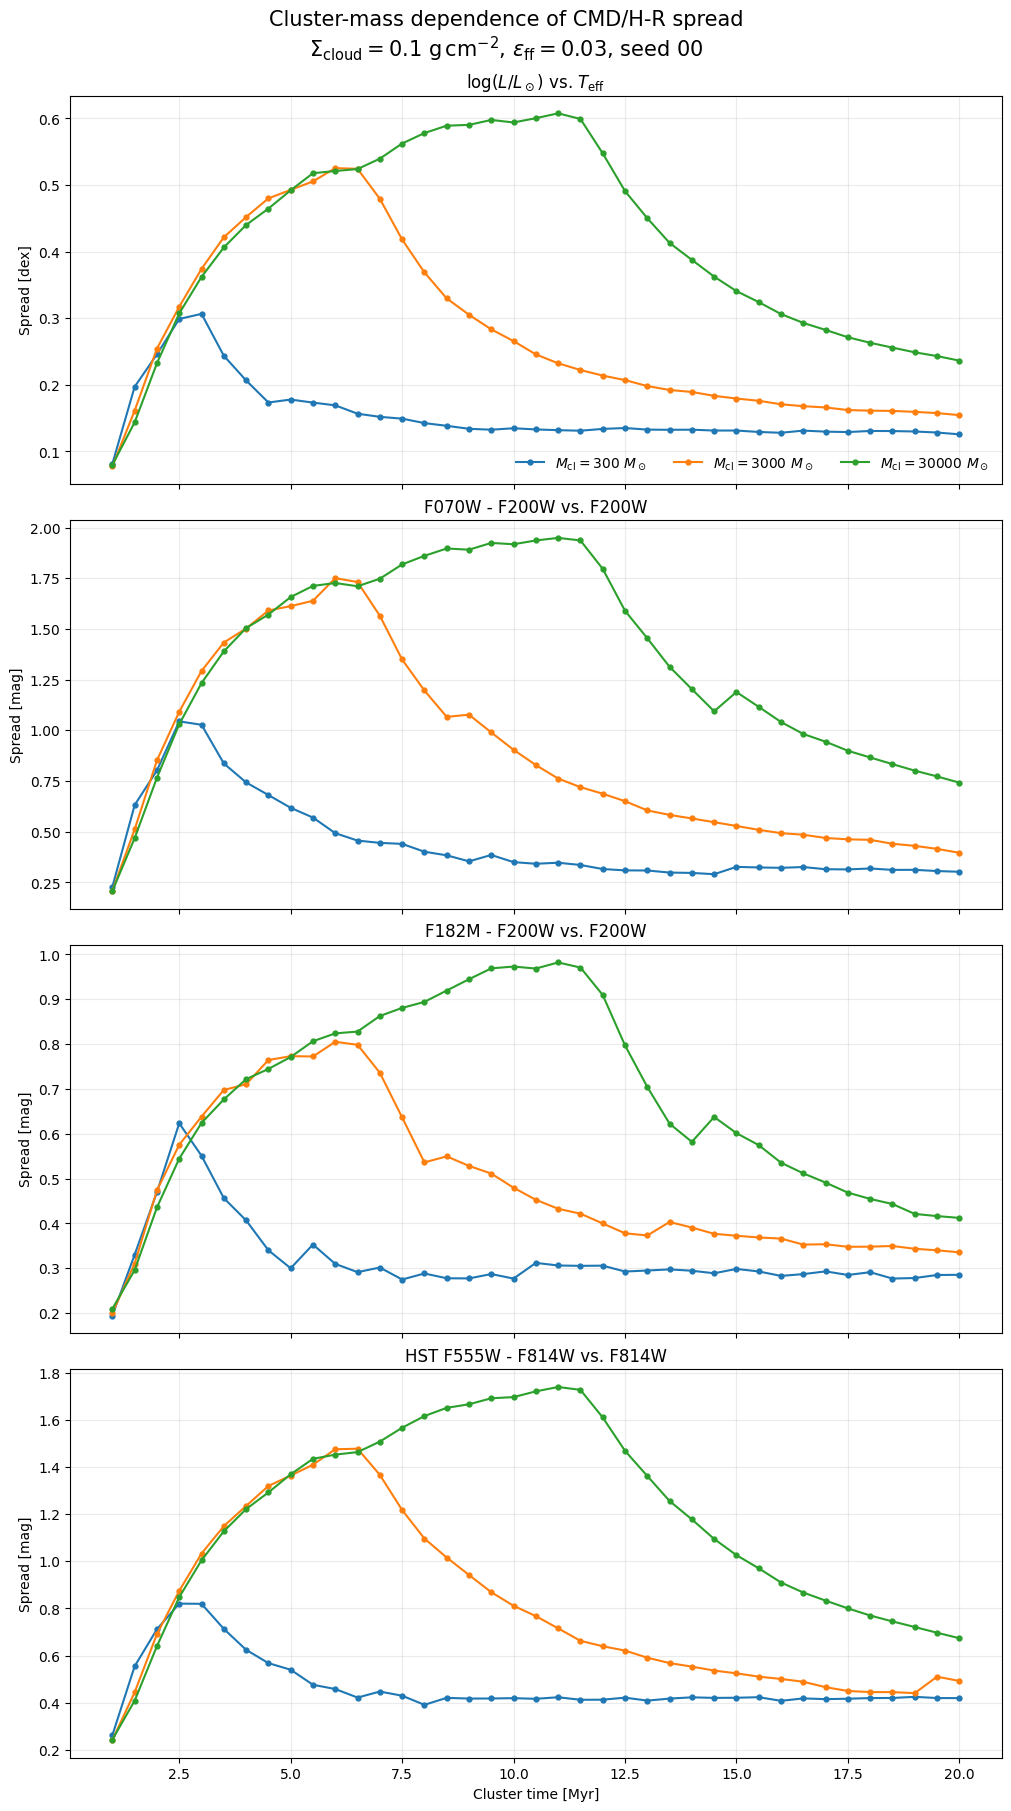

In [16]:
fig, axes = plt.subplots(
    len(DIAGRAMS), 1, figsize=(10.0, 4.5 * len(DIAGRAMS)),
    constrained_layout=True, sharex=True,
)
if len(DIAGRAMS) == 1:
    axes = [axes]

for ax, diagram in zip(axes, DIAGRAMS):
    for cluster_mass in SIMULATION_PATHS:
        sub = df_metrics[
            (df_metrics['cluster_mass_msun'] == int(cluster_mass))
            & (df_metrics['diagram'] == diagram.key)
        ].sort_values('snapshot_time_myr')
        if sub.empty:
            continue
        ax.plot(
            sub['snapshot_time_myr'], sub['spread_metric'],
            marker='o', ms=3.5, lw=1.5,
            label=rf'$M_{{\rm cl}}={cluster_mass:g}\ M_\odot$',
        )
    ax.set_ylabel(f'Spread [{diagram_unit(diagram)}]')
    ax.set_title(diagram.title)
    ax.grid(alpha=0.25)

axes[-1].set_xlabel('Cluster time [Myr]')
axes[0].legend(frameon=False, ncol=3)
fig.suptitle(
    'Cluster-mass dependence of CMD/H-R spread\n'
    + rf'$\Sigma_{{\rm cloud}}={SIGMA_CLOUD:g}\ {{\rm g\,cm^{{-2}}}}$, '
    + rf'$\epsilon_{{\rm ff}}={EPSILON_FF:g}$, seed {SEED}',
    fontsize=15,
)
finish_figure(fig, 'spread_by_cluster_mass_all_diagrams.png')

## Relative spread versus M_cl = 3000 Msun

Secondary diagnostic for fractional differences among cluster masses.

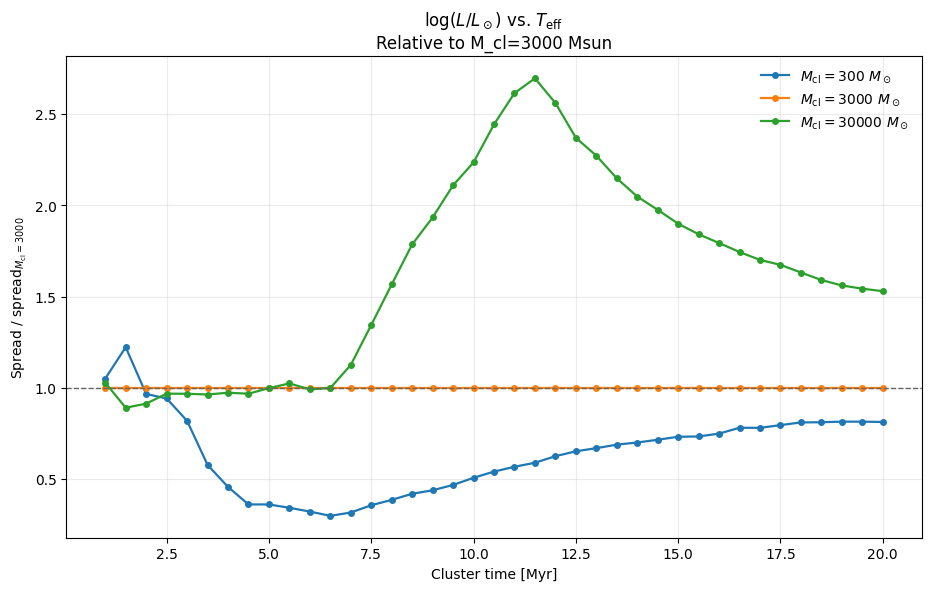

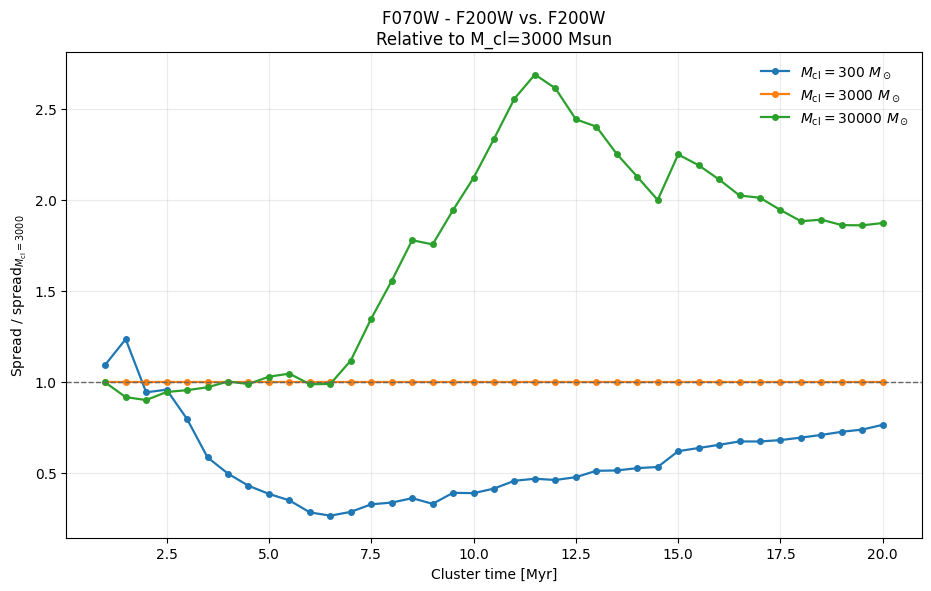

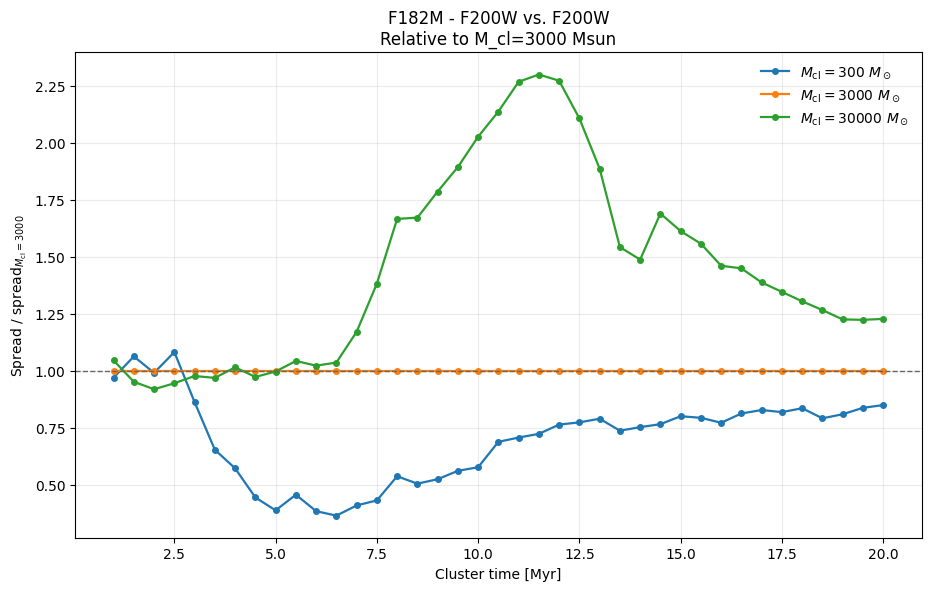

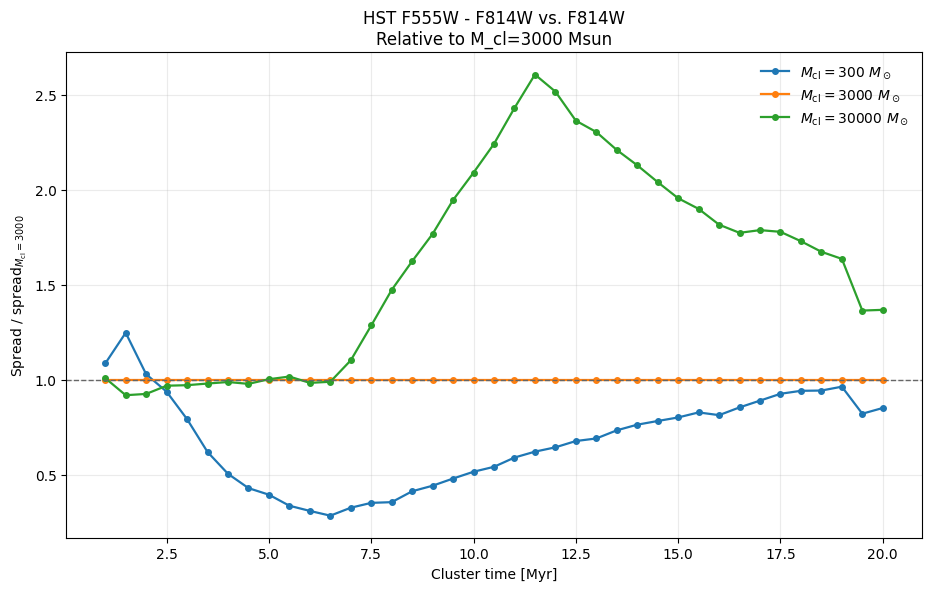

In [17]:
relative_rows = []
for diagram in DIAGRAMS:
    for time_myr in ANALYSIS_TIMES_MYR:
        time_myr = float(time_myr)
        base = df_metrics[
            (df_metrics['cluster_mass_msun'] == 3000)
            & np.isclose(df_metrics['snapshot_time_myr'], time_myr)
            & (df_metrics['diagram'] == diagram.key)
        ]
        if len(base) != 1:
            continue
        baseline = float(base.iloc[0]['spread_metric'])
        for cluster_mass in SIMULATION_PATHS:
            row = df_metrics[
                (df_metrics['cluster_mass_msun'] == int(cluster_mass))
                & np.isclose(df_metrics['snapshot_time_myr'], time_myr)
                & (df_metrics['diagram'] == diagram.key)
            ]
            if len(row) != 1:
                continue
            value = float(row.iloc[0]['spread_metric'])
            ratio = (
                value / baseline
                if np.isfinite(value) and np.isfinite(baseline)
                and not np.isclose(baseline, 0.0)
                else np.nan
            )
            relative_rows.append({
                'cluster_mass_msun': int(cluster_mass),
                'snapshot_time_myr': time_myr,
                'diagram': diagram.key, 'diagram_title': diagram.title,
                'spread_metric': value,
                'M3000_spread_metric': baseline,
                'spread_ratio_to_M3000': ratio,
            })


df_relative = pd.DataFrame(relative_rows)
df_relative.to_csv(OUTPUT_DIR / 'spread_relative_to_M3000.csv', index=False)

for diagram in DIAGRAMS:
    fig, ax = plt.subplots(figsize=(9.2, 5.8), constrained_layout=True)
    for cluster_mass in SIMULATION_PATHS:
        sub = df_relative[
            (df_relative['cluster_mass_msun'] == int(cluster_mass))
            & (df_relative['diagram'] == diagram.key)
        ].sort_values('snapshot_time_myr')
        if sub.empty:
            continue
        ax.plot(
            sub['snapshot_time_myr'], sub['spread_ratio_to_M3000'],
            marker='o', ms=4, lw=1.6,
            label=rf'$M_{{\rm cl}}={cluster_mass:g}\ M_\odot$',
        )
    ax.axhline(1.0, color='0.4', ls='--', lw=1.0)
    ax.set_xlabel('Cluster time [Myr]')
    ax.set_ylabel(r'Spread / spread$_{M_{\rm cl}=3000}$')
    ax.set_title(diagram.title + '\nRelative to M_cl=3000 Msun')
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    finish_figure(fig, f'spread_ratio_to_M3000_{diagram.key}.png')

## Metadata and output manifest

In [18]:
metadata = {
    'comparison': 'cluster mass',
    'cluster_masses_msun': [int(m) for m in SIMULATION_PATHS],
    'simulation_paths': {str(m): str(p) for m, p in SIMULATION_PATHS.items()},
    'sigma_cloud_g_cm2': SIGMA_CLOUD,
    'epsilon_ff': EPSILON_FF,
    'seed': SEED,
    'population_type': 'finite formation only',
    'temperature_selection': 'global 3000 <= Teff <= 3600 K',
    'reference_bin_age_myr': REFERENCE_BIN_AGE_MYR,
    'cmd_bin_definition': (
        '1 Myr color at 3000 K and 3600 K -> six equal-width fixed color bins'
    ),
    'hr_bin_definition': 'six fixed 100 K bins from 3000 to 3600 K',
    'minimum_stars_per_bin': MIN_STARS_PER_BIN,
    'analysis_times_myr': ANALYSIS_TIMES_MYR.tolist(),
    'display_times_myr': DISPLAY_TIMES_MYR.tolist(),
    'filters': FILTER_OBSMODES,
    'diagrams': [asdict(d) for d in DIAGRAMS],
    'notes': (
        'No seed averaging or error bars: one seed per cluster mass. '
        'M_cl=300 may have invalid bins because the same minimum of 8 stars '
        'per bin is intentionally retained for all masses.'
    ),
}
(OUTPUT_DIR / 'analysis_metadata.json').write_text(json.dumps(metadata, indent=2))

manifest = pd.DataFrame([
    ('isochrone_coverage.csv', 'SPISEA isochrone-grid coverage.'),
    ('static_1myr_bin_definitions.csv', 'Fixed H-R/CMD measurement-bin geometry.'),
    ('interpolation_accounting.csv', 'Interpolation accounting by mass and time.'),
    ('spread_metrics_by_mass_time_and_diagram.csv', 'Primary spread-metric table.'),
    ('spread_metrics_per_bin.csv', 'Per-bin star counts and spread measurements.'),
    ('metric_coverage_by_cluster_mass.csv', 'Valid-bin coverage by mass/time/diagram.'),
    ('metric_coverage_summary.csv', 'Compact coverage summary for sparse-bin diagnosis.'),
    ('spread_relative_to_M3000.csv', 'Spread ratio using M_cl=3000 as reference.'),
    ('time_evolution_M*_*.png', 'Time evolution for each mass and diagram.'),
    ('mass_snapshot_comparison_*.png', 'Same-age side-by-side mass comparison.'),
    ('spread_by_cluster_mass_*.png', 'Spread evolution with three masses overplotted.'),
    ('spread_by_cluster_mass_all_diagrams.png', 'Four-panel spread overview.'),
    ('spread_ratio_to_M3000_*.png', 'Fractional mass-effect diagnostic.'),
    ('analysis_metadata.json', 'Full analysis configuration.'),
], columns=['filename', 'description'])
manifest.to_csv(OUTPUT_DIR / 'output_manifest.csv', index=False)

print('=' * 80)
print('Cluster-mass comparison complete')
print('Outputs:', OUTPUT_DIR.resolve())
print('Cache:', CACHE_DIR.resolve())
print('Isochrone cache:', ISO_CACHE_DIR.resolve())
print('Primary result:', OUTPUT_DIR / 'spread_metrics_by_mass_time_and_diagram.csv')

Cluster-mass comparison complete
Outputs: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/09-10_M300vM3000vM30000/cluster_mass_comparison_seed00_outputs
Cache: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/09-10_M300vM3000vM30000/cluster_mass_comparison_seed00_cache
Isochrone cache: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/09-10_M300vM3000vM30000/iso_cache
Primary result: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/09-10_M300vM3000vM30000/cluster_mass_comparison_seed00_outputs/spread_metrics_by_mass_time_and_diagram.csv
